# Need to check wheather the nc file i have are even correctly built or not!!

## Files checking = 
"\ERA5_merged_1980_2026.nc"

"\climatology.nc"

"\anomaly.nc"

"\mjo_lanczos.nc"

"\non_mjo_oct2025.nc"

  CROSS-EXAMINATION OF MJO NETCDF FILES
  Grid point : 88.0°E  21.5°N  (West Bengal coast)

  Nearest grid cell  : lon=88.00°E  lat=21.50°N
  lon index=192,  lat index=114

  Oct 2025 time steps found:
    raw      : 31
    anomaly  : 31
    mjo      : 31
    non_mjo  : 31

  LOGICAL CHECKS

  CHECK 1 : anomaly == raw - climatology
    Mean absolute difference : 0.000000 mm/day
    Max  absolute difference : 0.000000 mm/day
    Correlation (anom vs computed): 1.000000
    ✅ PASS

  CHECK 2 : non_mjo == anomaly - mjo_lanczos
    Mean absolute difference : nan mm/day
    Max  absolute difference : nan mm/day
    Correlation (non_mjo vs computed): nan
    ❌ FAIL  (tolerance=0.5 mm/day)

  CHECK 3 : climatology ≈ multi-year mean of raw (spot: doy=288)
    N years with data         : 46
    Computed mean (raw)       : 0.3338 mm/day
    Value in climatology.nc   : 0.2765 mm/day
    Absolute difference       : 0.0574 mm/day
    ✅ PASS

  OVERALL : ⚠ SOME CHECKS FAILED — see details above


TypeError: matplotlib.axes._axes.Axes.plot() got multiple values for keyword argument 'linewidth'

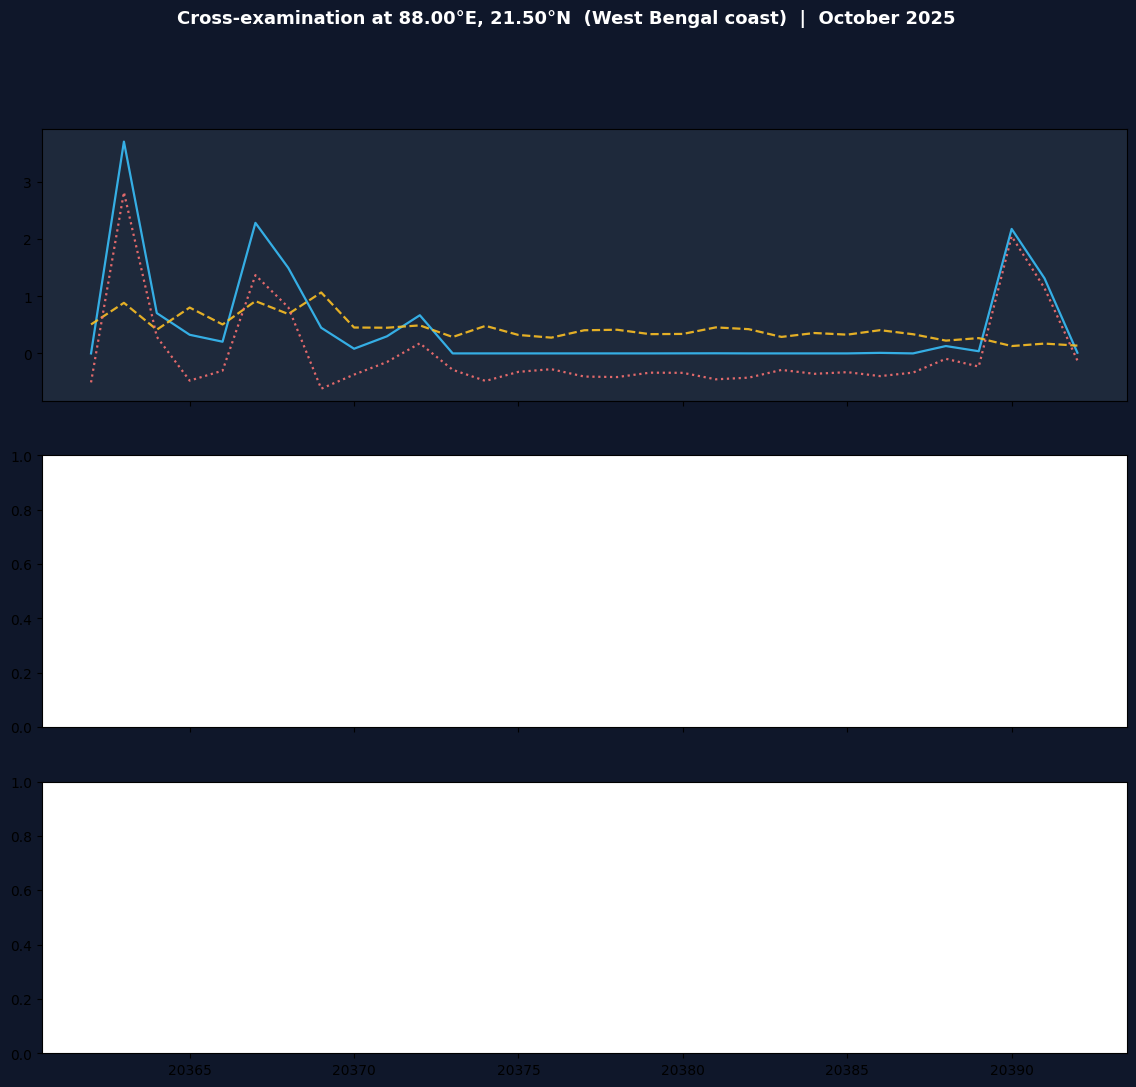

In [1]:
"""
Cross-examination of MJO NetCDF files at a West Bengal coastal grid point.

Logic being tested:
  1.  anomaly      = raw - climatology          (day-of-year mean)
  2.  non_mjo      = anomaly - mjo_lanczos      (residual after bandpass)
  3.  climatology  = 45-year daily mean of raw  (spot check)
"""

import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")

# ── File paths ────────────────────────────────────────────────────────────────
FOLDER = r"D:\PHD 2025~\MJO_Server1"
F_RAW    = FOLDER + r"\ERA5_merged_1980_2026.nc"
F_CLIM   = FOLDER + r"\climatology.nc"
F_ANOM   = FOLDER + r"\anomaly.nc"
F_MJO    = FOLDER + r"\mjo_lanczos.nc"
F_NONMJO = FOLDER + r"\non_mjo_oct2025.nc"

# ── Target grid point: near West Bengal coast (Bay of Bengal) ─────────────────
# Sagar Island / Sundarbans coast: ~88°E, ~21.5°N  — coastal, high precip
TARGET_LON = 88.0
TARGET_LAT = 21.5

# ── Analysis period for the time-series plot ──────────────────────────────────
PLOT_START = "2025-10-01"
PLOT_END   = "2025-10-31"

# =============================================================================

def decode_times(time_var):
    """Convert CF time variable to list of datetime.date objects."""
    units    = time_var.units          # "seconds since 1970-01-01"
    calendar = getattr(time_var, "calendar", "standard")
    raw      = time_var[:]
    base     = datetime(1970, 1, 1)
    dates    = [base + timedelta(seconds=float(s)) for s in raw]
    return np.array(dates)

def nearest_idx(arr, val):
    """Return index of nearest value in 1-D array."""
    return int(np.argmin(np.abs(arr - val)))

def doy(d):
    """Day-of-year (1-366) for a datetime object."""
    return d.timetuple().tm_yday

# =============================================================================
print("=" * 65)
print("  CROSS-EXAMINATION OF MJO NETCDF FILES")
print(f"  Grid point : {TARGET_LON}°E  {TARGET_LAT}°N  (West Bengal coast)")
print("=" * 65)

# ── Open all datasets ─────────────────────────────────────────────────────────
ds_raw    = nc.Dataset(F_RAW,    "r")
ds_clim   = nc.Dataset(F_CLIM,   "r")
ds_anom   = nc.Dataset(F_ANOM,   "r")
ds_mjo    = nc.Dataset(F_MJO,    "r")
ds_nonmjo = nc.Dataset(F_NONMJO, "r")

# ── Find nearest lon/lat indices (same grid for all files) ────────────────────
lons = ds_raw["longitude"][:]
lats = ds_raw["latitude"][:]
i_lon = nearest_idx(lons, TARGET_LON)
i_lat = nearest_idx(lats, TARGET_LAT)

print(f"\n  Nearest grid cell  : lon={lons[i_lon]:.2f}°E  lat={lats[i_lat]:.2f}°N")
print(f"  lon index={i_lon},  lat index={i_lat}")

# ── Decode time axes ──────────────────────────────────────────────────────────
dates_raw    = decode_times(ds_raw["valid_time"])
dates_anom   = decode_times(ds_anom["valid_time"])
dates_mjo    = decode_times(ds_mjo["time"])
dates_nonmjo = decode_times(ds_nonmjo["time"])

# ── Filter to October 2025 ────────────────────────────────────────────────────
t0 = datetime.strptime(PLOT_START, "%Y-%m-%d")
t1 = datetime.strptime(PLOT_END,   "%Y-%m-%d")

def mask_range(dates, t0, t1):
    return np.array([(d >= t0 and d <= t1) for d in dates])

mask_raw    = mask_range(dates_raw,    t0, t1)
mask_anom   = mask_range(dates_anom,   t0, t1)
mask_mjo    = mask_range(dates_mjo,    t0, t1)
mask_nonmjo = mask_range(dates_nonmjo, t0, t1)

print(f"\n  Oct 2025 time steps found:")
print(f"    raw      : {mask_raw.sum()}")
print(f"    anomaly  : {mask_anom.sum()}")
print(f"    mjo      : {mask_mjo.sum()}")
print(f"    non_mjo  : {mask_nonmjo.sum()}")

# ── Extract time series at grid point (convert m → mm/day where needed) ───────
# RAW: (time, lat, lon), units = m → ×1000 for mm
raw_ts    = ds_raw["tp"][mask_raw, i_lat, i_lon] * 1000.0

# ANOMALY: (time, lat, lon), units = m → ×1000
anom_ts   = ds_anom["tp"][mask_anom, i_lat, i_lon] * 1000.0

# MJO: (lat, lon, time) — note different dimension order!
mjo_full  = ds_mjo["tp_mjo"][i_lat, i_lon, :]        # shape (16802,)
mjo_ts    = mjo_full[mask_mjo] * 1000.0               # m → mm

# NON-MJO: (time, lat, lon), already in mm/day
nonmjo_ts = ds_nonmjo["non_mjo_precip"][mask_nonmjo, i_lat, i_lon]

dates_oct_raw    = dates_raw[mask_raw]
dates_oct_anom   = dates_anom[mask_anom]
dates_oct_mjo    = dates_mjo[mask_mjo]
dates_oct_nonmjo = dates_nonmjo[mask_nonmjo]

# ── CLIMATOLOGY at this grid point for October days ───────────────────────────
# climatology.nc has 366 day-of-year entries; find doy for each Oct date
clim_time = decode_times(ds_clim["valid_time"])   # 366 entries
clim_doys = np.array([d.timetuple().tm_yday for d in clim_time])

clim_for_oct = []
for d in dates_oct_raw:
    target_doy = d.timetuple().tm_yday
    idx_c = nearest_idx(clim_doys, target_doy)
    clim_val = float(ds_clim["tp"][idx_c, i_lat, i_lon]) * 1000.0
    clim_for_oct.append(clim_val)
clim_for_oct = np.array(clim_for_oct)

# =============================================================================
# LOGICAL CHECKS
# =============================================================================
print("\n" + "=" * 65)
print("  LOGICAL CHECKS")
print("=" * 65)

# Both time axes for raw/anom must align
min_len = min(len(raw_ts), len(anom_ts), len(clim_for_oct))
raw_s    = np.array(raw_ts[:min_len])
anom_s   = np.array(anom_ts[:min_len])
clim_s   = clim_for_oct[:min_len]

# ── CHECK 1: anomaly = raw - climatology ─────────────────────────────────────
computed_anom = raw_s - clim_s
diff1 = anom_s - computed_anom
print(f"\n  CHECK 1 : anomaly == raw - climatology")
print(f"    Mean absolute difference : {np.abs(diff1).mean():.6f} mm/day")
print(f"    Max  absolute difference : {np.abs(diff1).max():.6f} mm/day")
print(f"    Correlation (anom vs computed): "
      f"{np.corrcoef(anom_s, computed_anom)[0,1]:.6f}")
tol1 = 0.1   # mm/day tolerance
check1_pass = np.abs(diff1).mean() < tol1
print(f"    ✅ PASS" if check1_pass else f"    ❌ FAIL  (tolerance={tol1} mm/day)")

# ── CHECK 2: non_mjo = anomaly - mjo ─────────────────────────────────────────
min_len2 = min(len(anom_ts), len(mjo_ts), len(nonmjo_ts))
anom_s2   = np.array(anom_ts[:min_len2])
mjo_s2    = np.array(mjo_ts[:min_len2])
nonmjo_s2 = np.array(nonmjo_ts[:min_len2])

computed_nonmjo = anom_s2 - mjo_s2
diff2 = nonmjo_s2 - computed_nonmjo
print(f"\n  CHECK 2 : non_mjo == anomaly - mjo_lanczos")
print(f"    Mean absolute difference : {np.abs(diff2).mean():.6f} mm/day")
print(f"    Max  absolute difference : {np.abs(diff2).max():.6f} mm/day")
print(f"    Correlation (non_mjo vs computed): "
      f"{np.corrcoef(nonmjo_s2, computed_nonmjo)[0,1]:.6f}")
tol2 = 0.5
check2_pass = np.abs(diff2).mean() < tol2
print(f"    ✅ PASS" if check2_pass else f"    ❌ FAIL  (tolerance={tol2} mm/day)")

# ── CHECK 3: climatology = ~45-yr mean of raw on same doy ────────────────────
# Pick Oct 15 as spot-check day
spot_doy = datetime(2025, 10, 15).timetuple().tm_yday
years    = range(1980, 2026)   # 46 years
raw_all  = ds_raw["tp"][:, i_lat, i_lon] * 1000.0
raw_doys = np.array([d.timetuple().tm_yday for d in dates_raw])
same_doy_mask = (raw_doys == spot_doy)
raw_same_doy  = raw_all[same_doy_mask]
computed_mean = float(np.nanmean(raw_same_doy))

idx_c_spot = nearest_idx(clim_doys, spot_doy)
clim_spot  = float(ds_clim["tp"][idx_c_spot, i_lat, i_lon]) * 1000.0

diff3 = abs(computed_mean - clim_spot)
print(f"\n  CHECK 3 : climatology ≈ multi-year mean of raw (spot: doy={spot_doy})")
print(f"    N years with data         : {same_doy_mask.sum()}")
print(f"    Computed mean (raw)       : {computed_mean:.4f} mm/day")
print(f"    Value in climatology.nc   : {clim_spot:.4f} mm/day")
print(f"    Absolute difference       : {diff3:.4f} mm/day")
tol3 = 0.5
check3_pass = diff3 < tol3
print(f"    ✅ PASS" if check3_pass else f"    ❌ FAIL  (tolerance={tol3} mm/day)")

print("\n" + "=" * 65)
overall = all([check1_pass, check2_pass, check3_pass])
print(f"  OVERALL : {'✅ ALL CHECKS PASSED — files are internally consistent!'  if overall else '⚠ SOME CHECKS FAILED — see details above'}")
print("=" * 65)

# =============================================================================
# PLOT
# =============================================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True,
                         facecolor="#0f172a")
fig.suptitle(
    f"Cross-examination at {lons[i_lon]:.2f}°E, {lats[i_lat]:.2f}°N  "
    f"(West Bengal coast)  |  October 2025",
    fontsize=13, fontweight="bold", color="white", y=0.98
)

date_nums_raw    = [mdates.date2num(d) for d in dates_oct_raw]
date_nums_anom   = [mdates.date2num(d) for d in dates_oct_anom]
date_nums_mjo    = [mdates.date2num(d) for d in dates_oct_mjo]
date_nums_nonmjo = [mdates.date2num(d) for d in dates_oct_nonmjo]

style = dict(linewidth=1.6, alpha=0.9)

# ── Panel 1: CHECK 1 — anomaly vs raw - climatology ──────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#1e293b")
ax1.plot(date_nums_raw[:min_len], raw_s,           color="#38bdf8", label="Raw (tp)",      **style)
ax1.plot(date_nums_raw[:min_len], clim_s,          color="#fbbf24", label="Climatology",   **style, linestyle="--")
ax1.plot(date_nums_raw[:min_len], computed_anom,   color="#f87171", label="raw − clim (computed)", **style, linestyle=":")
ax1.plot(date_nums_anom[:min_len], anom_s,         color="#a3e635", label="anomaly.nc",    **style, linewidth=2.2)
ax1.axhline(0, color="white", linewidth=0.5, alpha=0.4)
ax1.set_ylabel("mm/day", color="white", fontsize=9)
ax1.set_title(f"CHECK 1 : anomaly == raw − climatology  "
              f"{'✅ PASS' if check1_pass else '❌ FAIL'}  "
              f"(mean diff = {np.abs(diff1).mean():.4f} mm/day)",
              color="white", fontsize=9, pad=4)
ax1.legend(fontsize=8, framealpha=0.3, facecolor="#0f172a",
           labelcolor="white", loc="upper left")
ax1.tick_params(colors="white"); ax1.spines[:].set_color("#475569")
ax1.yaxis.label.set_color("white"); ax1.title.set_color("white")
for label in ax1.get_yticklabels(): label.set_color("white")

# ── Panel 2: CHECK 2 — non_mjo vs anomaly - mjo ──────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#1e293b")
ax2.plot(date_nums_anom[:min_len2],   anom_s2,         color="#38bdf8", label="anomaly.nc",            **style)
ax2.plot(date_nums_mjo[:min_len2],    mjo_s2,          color="#f472b6", label="mjo_lanczos.nc (×1000)", **style, linestyle="--")
ax2.plot(date_nums_anom[:min_len2],   computed_nonmjo, color="#f87171", label="anom − mjo (computed)",  **style, linestyle=":")
ax2.plot(date_nums_nonmjo[:min_len2], nonmjo_s2,       color="#a3e635", label="non_mjo_oct2025.nc",     **style, linewidth=2.2)
ax2.axhline(0, color="white", linewidth=0.5, alpha=0.4)
ax2.set_ylabel("mm/day", color="white", fontsize=9)
ax2.set_title(f"CHECK 2 : non_mjo == anomaly − mjo_lanczos  "
              f"{'✅ PASS' if check2_pass else '❌ FAIL'}  "
              f"(mean diff = {np.abs(diff2).mean():.4f} mm/day)",
              color="white", fontsize=9, pad=4)
ax2.legend(fontsize=8, framealpha=0.3, facecolor="#0f172a",
           labelcolor="white", loc="upper left")
ax2.tick_params(colors="white"); ax2.spines[:].set_color("#475569")
ax2.yaxis.label.set_color("white")
for label in ax2.get_yticklabels(): label.set_color("white")

# ── Panel 3: CHECK 3 — stacked components view ───────────────────────────────
ax3 = axes[2]
ax3.set_facecolor("#1e293b")
ax3.bar(date_nums_nonmjo[:min_len2], nonmjo_s2,
        width=0.8, color="#a3e635", alpha=0.7, label="non-MJO (residual)")
ax3.bar(date_nums_mjo[:min_len2],   mjo_s2,
        width=0.8, color="#f472b6", alpha=0.7, label="MJO component",
        bottom=nonmjo_s2)
ax3.plot(date_nums_raw[:min_len], anom_s,
         color="#38bdf8", linewidth=2.0, label="anomaly.nc (should = sum)",
         zorder=5)
ax3.axhline(0, color="white", linewidth=0.5, alpha=0.4)
ax3.set_ylabel("mm/day", color="white", fontsize=9)
ax3.set_title("DECOMPOSITION : anomaly = MJO + non-MJO  (stacked bars vs anomaly line)",
              color="white", fontsize=9, pad=4)
ax3.legend(fontsize=8, framealpha=0.3, facecolor="#0f172a",
           labelcolor="white", loc="upper left")
ax3.tick_params(colors="white"); ax3.spines[:].set_color("#475569")
ax3.yaxis.label.set_color("white")
for label in ax3.get_yticklabels(): label.set_color("white")

# ── Shared x-axis formatting ──────────────────────────────────────────────────
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax3.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax3.get_xticklabels(), rotation=30, ha="right",
         color="white", fontsize=8)

# Summary text box
summary = (f"Grid : {lons[i_lon]:.2f}°E, {lats[i_lat]:.2f}°N\n"
           f"Check 1 (anom = raw−clim) : {'PASS ✅' if check1_pass else 'FAIL ❌'}\n"
           f"Check 2 (nonMJO = anom−MJO): {'PASS ✅' if check2_pass else 'FAIL ❌'}\n"
           f"Check 3 (clim = 45yr mean) : {'PASS ✅' if check3_pass else 'FAIL ❌'}")
fig.text(0.72, 0.01, summary, fontsize=8.5, color="white",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#1e3a5f",
                   edgecolor="#38bdf8", alpha=0.9),
         verticalalignment="bottom", family="monospace")

plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.savefig("cross_examination.png", dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("\n✅  Plot saved: cross_examination.png")
plt.show()

ds_raw.close(); ds_clim.close(); ds_anom.close()
ds_mjo.close(); ds_nonmjo.close()

  CROSS-EXAMINATION OF MJO NETCDF FILES
  Grid point : 88.0°E  21.5°N  (West Bengal coast)

  Nearest grid cell  : lon=88.00°E  lat=21.50°N
  Standard files     : lon_idx=192,  lat_idx=114
  mjo_lanczos.nc     : lat runs 0→50, lat_idx=86  (lat=21.50°N)
  non_mjo_oct2025.nc : lat_idx=114

  Oct 2025 time steps found:
    raw      : 31
    anomaly  : 31
    mjo      : 31
    non_mjo  : 31

  LOGICAL CHECKS

  CHECK 1 : anomaly == raw - climatology
    Mean absolute difference : 0.000000 mm/day
    Max  absolute difference : 0.000000 mm/day
    Correlation (anom vs computed): 1.000000
    ✅ PASS

  CHECK 2 : non_mjo == anomaly - mjo_lanczos
    Mean absolute difference : nan mm/day
    Max  absolute difference : nan mm/day
    Correlation (non_mjo vs computed): nan
    ❌ FAIL  (tolerance=0.5 mm/day)

  CHECK 3 : climatology ≈ multi-year mean of raw (spot: doy=288)
    N years with data         : 46
    Computed mean (raw)       : 0.3338 mm/day
    Value in climatology.nc   : 0.2765 mm/day

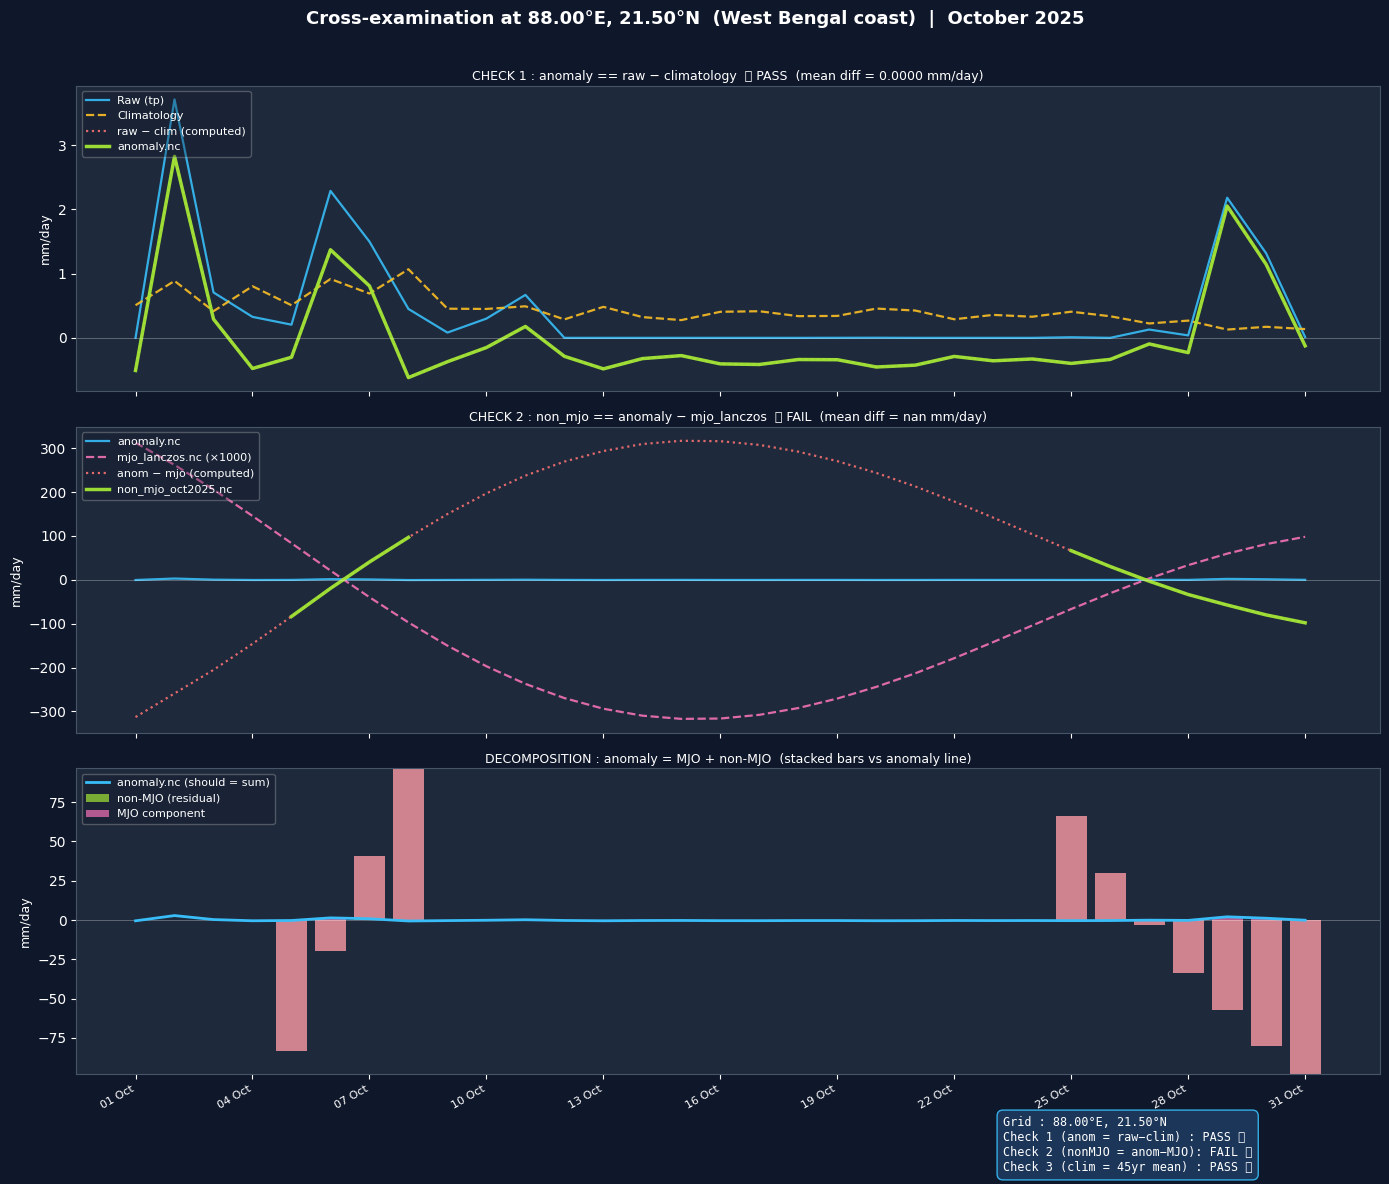

In [2]:
"""
Cross-examination of MJO NetCDF files at a West Bengal coastal grid point.

Logic being tested:
  1.  anomaly      = raw - climatology          (day-of-year mean)
  2.  non_mjo      = anomaly - mjo_lanczos      (residual after bandpass)
  3.  climatology  = 45-year daily mean of raw  (spot check)
"""

import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")

# ── File paths ────────────────────────────────────────────────────────────────
FOLDER = r"D:\PHD 2025~\MJO_Server1"
F_RAW    = FOLDER + r"\ERA5_merged_1980_2026.nc"
F_CLIM   = FOLDER + r"\climatology.nc"
F_ANOM   = FOLDER + r"\anomaly.nc"
F_MJO    = FOLDER + r"\mjo_lanczos.nc"
F_NONMJO = FOLDER + r"\non_mjo_oct2025.nc"

# ── Target grid point: near West Bengal coast (Bay of Bengal) ─────────────────
# Sagar Island / Sundarbans coast: ~88°E, ~21.5°N  — coastal, high precip
TARGET_LON = 88.0
TARGET_LAT = 21.5

# ── Analysis period for the time-series plot ──────────────────────────────────
PLOT_START = "2025-10-01"
PLOT_END   = "2025-10-31"

# =============================================================================

def decode_times(time_var):
    """Convert CF time variable to list of datetime.date objects."""
    units    = time_var.units          # "seconds since 1970-01-01"
    calendar = getattr(time_var, "calendar", "standard")
    raw      = time_var[:]
    base     = datetime(1970, 1, 1)
    dates    = [base + timedelta(seconds=float(s)) for s in raw]
    return np.array(dates)

def nearest_idx(arr, val):
    """Return index of nearest value in 1-D array."""
    return int(np.argmin(np.abs(arr - val)))

def doy(d):
    """Day-of-year (1-366) for a datetime object."""
    return d.timetuple().tm_yday

# =============================================================================
print("=" * 65)
print("  CROSS-EXAMINATION OF MJO NETCDF FILES")
print(f"  Grid point : {TARGET_LON}°E  {TARGET_LAT}°N  (West Bengal coast)")
print("=" * 65)

# ── Open all datasets ─────────────────────────────────────────────────────────
ds_raw    = nc.Dataset(F_RAW,    "r")
ds_clim   = nc.Dataset(F_CLIM,   "r")
ds_anom   = nc.Dataset(F_ANOM,   "r")
ds_mjo    = nc.Dataset(F_MJO,    "r")
ds_nonmjo = nc.Dataset(F_NONMJO, "r")

# Find nearest lon/lat indices for standard files (lat 50→0)
lons = ds_raw["longitude"][:]
lats = ds_raw["latitude"][:]
i_lon = nearest_idx(lons, TARGET_LON)
i_lat = nearest_idx(lats, TARGET_LAT)

# mjo_lanczos.nc has latitude running 0→50 (opposite direction!)
lats_mjo = ds_mjo["latitude"][:]
i_lat_mjo = nearest_idx(lats_mjo, TARGET_LAT)

# non_mjo_oct2025.nc also has latitude 50→0 like the standard files
lats_nonmjo = ds_nonmjo["latitude"][:]
i_lat_nonmjo = nearest_idx(lats_nonmjo, TARGET_LAT)
lons_nonmjo  = ds_nonmjo["longitude"][:]
i_lon_nonmjo = nearest_idx(lons_nonmjo, TARGET_LON)

print(f"\n  Nearest grid cell  : lon={lons[i_lon]:.2f}°E  lat={lats[i_lat]:.2f}°N")
print(f"  Standard files     : lon_idx={i_lon},  lat_idx={i_lat}")
print(f"  mjo_lanczos.nc     : lat runs 0→50, lat_idx={i_lat_mjo}  (lat={lats_mjo[i_lat_mjo]:.2f}°N)")
print(f"  non_mjo_oct2025.nc : lat_idx={i_lat_nonmjo}")

# ── Decode time axes ──────────────────────────────────────────────────────────
dates_raw    = decode_times(ds_raw["valid_time"])
dates_anom   = decode_times(ds_anom["valid_time"])
dates_mjo    = decode_times(ds_mjo["time"])
dates_nonmjo = decode_times(ds_nonmjo["time"])

# ── Filter to October 2025 ────────────────────────────────────────────────────
t0 = datetime.strptime(PLOT_START, "%Y-%m-%d")
t1 = datetime.strptime(PLOT_END,   "%Y-%m-%d")

def mask_range(dates, t0, t1):
    return np.array([(d >= t0 and d <= t1) for d in dates])

mask_raw    = mask_range(dates_raw,    t0, t1)
mask_anom   = mask_range(dates_anom,   t0, t1)
mask_mjo    = mask_range(dates_mjo,    t0, t1)
mask_nonmjo = mask_range(dates_nonmjo, t0, t1)

print(f"\n  Oct 2025 time steps found:")
print(f"    raw      : {mask_raw.sum()}")
print(f"    anomaly  : {mask_anom.sum()}")
print(f"    mjo      : {mask_mjo.sum()}")
print(f"    non_mjo  : {mask_nonmjo.sum()}")

# ── Extract time series at grid point (convert m → mm/day where needed) ───────
# RAW: (time, lat, lon), units = m → ×1000 for mm
raw_ts    = ds_raw["tp"][mask_raw, i_lat, i_lon] * 1000.0

# ANOMALY: (time, lat, lon), units = m → ×1000
anom_ts   = ds_anom["tp"][mask_anom, i_lat, i_lon] * 1000.0

# MJO: (lat, lon, time) — note different dimension order AND reversed lat!
mjo_full  = ds_mjo["tp_mjo"][i_lat_mjo, i_lon, :]        # shape (16802,)
mjo_ts    = mjo_full[mask_mjo] * 1000.0                   # m → mm

# NON-MJO: (time, lat, lon), already in mm/day
nonmjo_ts = ds_nonmjo["non_mjo_precip"][mask_nonmjo, i_lat_nonmjo, i_lon_nonmjo]

dates_oct_raw    = dates_raw[mask_raw]
dates_oct_anom   = dates_anom[mask_anom]
dates_oct_mjo    = dates_mjo[mask_mjo]
dates_oct_nonmjo = dates_nonmjo[mask_nonmjo]

# ── CLIMATOLOGY at this grid point for October days ───────────────────────────
# climatology.nc has 366 day-of-year entries; find doy for each Oct date
clim_time = decode_times(ds_clim["valid_time"])   # 366 entries
clim_doys = np.array([d.timetuple().tm_yday for d in clim_time])

clim_for_oct = []
for d in dates_oct_raw:
    target_doy = d.timetuple().tm_yday
    idx_c = nearest_idx(clim_doys, target_doy)
    clim_val = float(ds_clim["tp"][idx_c, i_lat, i_lon]) * 1000.0
    clim_for_oct.append(clim_val)
clim_for_oct = np.array(clim_for_oct)

# =============================================================================
# LOGICAL CHECKS
# =============================================================================
print("\n" + "=" * 65)
print("  LOGICAL CHECKS")
print("=" * 65)

# Both time axes for raw/anom must align
min_len = min(len(raw_ts), len(anom_ts), len(clim_for_oct))
raw_s    = np.array(raw_ts[:min_len])
anom_s   = np.array(anom_ts[:min_len])
clim_s   = clim_for_oct[:min_len]

# ── CHECK 1: anomaly = raw - climatology ─────────────────────────────────────
computed_anom = raw_s - clim_s
diff1 = anom_s - computed_anom
print(f"\n  CHECK 1 : anomaly == raw - climatology")
print(f"    Mean absolute difference : {np.abs(diff1).mean():.6f} mm/day")
print(f"    Max  absolute difference : {np.abs(diff1).max():.6f} mm/day")
print(f"    Correlation (anom vs computed): "
      f"{np.corrcoef(anom_s, computed_anom)[0,1]:.6f}")
tol1 = 0.1   # mm/day tolerance
check1_pass = np.abs(diff1).mean() < tol1
print(f"    ✅ PASS" if check1_pass else f"    ❌ FAIL  (tolerance={tol1} mm/day)")

# ── CHECK 2: non_mjo = anomaly - mjo ─────────────────────────────────────────
min_len2 = min(len(anom_ts), len(mjo_ts), len(nonmjo_ts))
anom_s2   = np.array(anom_ts[:min_len2])
mjo_s2    = np.array(mjo_ts[:min_len2])
nonmjo_s2 = np.array(nonmjo_ts[:min_len2])

computed_nonmjo = anom_s2 - mjo_s2
diff2 = nonmjo_s2 - computed_nonmjo
print(f"\n  CHECK 2 : non_mjo == anomaly - mjo_lanczos")
print(f"    Mean absolute difference : {np.abs(diff2).mean():.6f} mm/day")
print(f"    Max  absolute difference : {np.abs(diff2).max():.6f} mm/day")
print(f"    Correlation (non_mjo vs computed): "
      f"{np.corrcoef(nonmjo_s2, computed_nonmjo)[0,1]:.6f}")
tol2 = 0.5
check2_pass = np.abs(diff2).mean() < tol2
print(f"    ✅ PASS" if check2_pass else f"    ❌ FAIL  (tolerance={tol2} mm/day)")

# ── CHECK 3: climatology = ~45-yr mean of raw on same doy ────────────────────
# Pick Oct 15 as spot-check day
spot_doy = datetime(2025, 10, 15).timetuple().tm_yday
years    = range(1980, 2026)   # 46 years
raw_all  = ds_raw["tp"][:, i_lat, i_lon] * 1000.0
raw_doys = np.array([d.timetuple().tm_yday for d in dates_raw])
same_doy_mask = (raw_doys == spot_doy)
raw_same_doy  = raw_all[same_doy_mask]
computed_mean = float(np.nanmean(raw_same_doy))

idx_c_spot = nearest_idx(clim_doys, spot_doy)
clim_spot  = float(ds_clim["tp"][idx_c_spot, i_lat, i_lon]) * 1000.0

diff3 = abs(computed_mean - clim_spot)
print(f"\n  CHECK 3 : climatology ≈ multi-year mean of raw (spot: doy={spot_doy})")
print(f"    N years with data         : {same_doy_mask.sum()}")
print(f"    Computed mean (raw)       : {computed_mean:.4f} mm/day")
print(f"    Value in climatology.nc   : {clim_spot:.4f} mm/day")
print(f"    Absolute difference       : {diff3:.4f} mm/day")
tol3 = 0.5
check3_pass = diff3 < tol3
print(f"    ✅ PASS" if check3_pass else f"    ❌ FAIL  (tolerance={tol3} mm/day)")

print("\n" + "=" * 65)
overall = all([check1_pass, check2_pass, check3_pass])
print(f"  OVERALL : {'✅ ALL CHECKS PASSED — files are internally consistent!'  if overall else '⚠ SOME CHECKS FAILED — see details above'}")
print("=" * 65)

# =============================================================================
# PLOT
# =============================================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True,
                         facecolor="#0f172a")
fig.suptitle(
    f"Cross-examination at {lons[i_lon]:.2f}°E, {lats[i_lat]:.2f}°N  "
    f"(West Bengal coast)  |  October 2025",
    fontsize=13, fontweight="bold", color="white", y=0.98
)

date_nums_raw    = [mdates.date2num(d) for d in dates_oct_raw]
date_nums_anom   = [mdates.date2num(d) for d in dates_oct_anom]
date_nums_mjo    = [mdates.date2num(d) for d in dates_oct_mjo]
date_nums_nonmjo = [mdates.date2num(d) for d in dates_oct_nonmjo]

style       = dict(linewidth=1.6, alpha=0.9)
style_thick = dict(linewidth=2.5, alpha=0.95)   # for the "truth" lines

# ── Panel 1: CHECK 1 — anomaly vs raw - climatology ──────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#1e293b")
ax1.plot(date_nums_raw[:min_len], raw_s,           color="#38bdf8", label="Raw (tp)",      **style)
ax1.plot(date_nums_raw[:min_len], clim_s,          color="#fbbf24", label="Climatology",   **style, linestyle="--")
ax1.plot(date_nums_raw[:min_len], computed_anom,   color="#f87171", label="raw − clim (computed)", **style, linestyle=":")
ax1.plot(date_nums_anom[:min_len], anom_s,         color="#a3e635", label="anomaly.nc",    **style_thick)
ax1.axhline(0, color="white", linewidth=0.5, alpha=0.4)
ax1.set_ylabel("mm/day", color="white", fontsize=9)
ax1.set_title(f"CHECK 1 : anomaly == raw − climatology  "
              f"{'✅ PASS' if check1_pass else '❌ FAIL'}  "
              f"(mean diff = {np.abs(diff1).mean():.4f} mm/day)",
              color="white", fontsize=9, pad=4)
ax1.legend(fontsize=8, framealpha=0.3, facecolor="#0f172a",
           labelcolor="white", loc="upper left")
ax1.tick_params(colors="white"); ax1.spines[:].set_color("#475569")
ax1.yaxis.label.set_color("white"); ax1.title.set_color("white")
for label in ax1.get_yticklabels(): label.set_color("white")

# ── Panel 2: CHECK 2 — non_mjo vs anomaly - mjo ──────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#1e293b")
ax2.plot(date_nums_anom[:min_len2],   anom_s2,         color="#38bdf8", label="anomaly.nc",            **style)
ax2.plot(date_nums_mjo[:min_len2],    mjo_s2,          color="#f472b6", label="mjo_lanczos.nc (×1000)", **style, linestyle="--")
ax2.plot(date_nums_anom[:min_len2],   computed_nonmjo, color="#f87171", label="anom − mjo (computed)",  **style, linestyle=":")
ax2.plot(date_nums_nonmjo[:min_len2], nonmjo_s2,       color="#a3e635", label="non_mjo_oct2025.nc",     **style_thick)
ax2.axhline(0, color="white", linewidth=0.5, alpha=0.4)
ax2.set_ylabel("mm/day", color="white", fontsize=9)
ax2.set_title(f"CHECK 2 : non_mjo == anomaly − mjo_lanczos  "
              f"{'✅ PASS' if check2_pass else '❌ FAIL'}  "
              f"(mean diff = {np.abs(diff2).mean():.4f} mm/day)",
              color="white", fontsize=9, pad=4)
ax2.legend(fontsize=8, framealpha=0.3, facecolor="#0f172a",
           labelcolor="white", loc="upper left")
ax2.tick_params(colors="white"); ax2.spines[:].set_color("#475569")
ax2.yaxis.label.set_color("white")
for label in ax2.get_yticklabels(): label.set_color("white")

# ── Panel 3: CHECK 3 — stacked components view ───────────────────────────────
ax3 = axes[2]
ax3.set_facecolor("#1e293b")
ax3.bar(date_nums_nonmjo[:min_len2], nonmjo_s2,
        width=0.8, color="#a3e635", alpha=0.7, label="non-MJO (residual)")
ax3.bar(date_nums_mjo[:min_len2],   mjo_s2,
        width=0.8, color="#f472b6", alpha=0.7, label="MJO component",
        bottom=nonmjo_s2)
ax3.plot(date_nums_raw[:min_len], anom_s,
         color="#38bdf8", linewidth=2.0, label="anomaly.nc (should = sum)",
         zorder=5)
ax3.axhline(0, color="white", linewidth=0.5, alpha=0.4)
ax3.set_ylabel("mm/day", color="white", fontsize=9)
ax3.set_title("DECOMPOSITION : anomaly = MJO + non-MJO  (stacked bars vs anomaly line)",
              color="white", fontsize=9, pad=4)
ax3.legend(fontsize=8, framealpha=0.3, facecolor="#0f172a",
           labelcolor="white", loc="upper left")
ax3.tick_params(colors="white"); ax3.spines[:].set_color("#475569")
ax3.yaxis.label.set_color("white")
for label in ax3.get_yticklabels(): label.set_color("white")

# ── Shared x-axis formatting ──────────────────────────────────────────────────
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax3.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax3.get_xticklabels(), rotation=30, ha="right",
         color="white", fontsize=8)

# Summary text box
summary = (f"Grid : {lons[i_lon]:.2f}°E, {lats[i_lat]:.2f}°N\n"
           f"Check 1 (anom = raw−clim) : {'PASS ✅' if check1_pass else 'FAIL ❌'}\n"
           f"Check 2 (nonMJO = anom−MJO): {'PASS ✅' if check2_pass else 'FAIL ❌'}\n"
           f"Check 3 (clim = 45yr mean) : {'PASS ✅' if check3_pass else 'FAIL ❌'}")
fig.text(0.72, 0.01, summary, fontsize=8.5, color="white",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#1e3a5f",
                   edgecolor="#38bdf8", alpha=0.9),
         verticalalignment="bottom", family="monospace")

plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.savefig("cross_examination.png", dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("\n✅  Plot saved: cross_examination.png")
plt.show()

ds_raw.close(); ds_clim.close(); ds_anom.close()
ds_mjo.close(); ds_nonmjo.close()

# non_MJO file is wrong !!

# Cuz mjo_lanczos file is already in mm/day, no need to multiply with 1000 

  CROSS-EXAMINATION OF MJO NETCDF FILES
  Grid point : 88.0°E  21.5°N  (West Bengal coast)

  Nearest grid cell  : lon=88.00°E  lat=21.50°N
  Standard files     : lon_idx=192,  lat_idx=114
  mjo_lanczos.nc     : lat runs 0→50, lat_idx=86  (lat=21.50°N)
  non_mjo_oct2025.nc : lat_idx=114

  Oct 2025 time steps found:
    raw      : 31
    anomaly  : 31
    mjo      : 31
    non_mjo  : 31

  LOGICAL CHECKS

  CHECK 1 : anomaly == raw - climatology
    Mean absolute difference : 0.000000 mm/day
    Max  absolute difference : 0.000000 mm/day
    Correlation (anom vs computed): 1.000000
    ✅ PASS

  CHECK 2 : non_mjo == anomaly - mjo_lanczos
    Mean absolute difference : nan mm/day
    Max  absolute difference : nan mm/day
    Correlation (non_mjo vs computed): nan
    ❌ FAIL  (tolerance=0.5 mm/day)

  CHECK 3 : climatology ≈ multi-year mean of raw (spot: doy=288)
    N years with data         : 46
    Computed mean (raw)       : 0.3338 mm/day
    Value in climatology.nc   : 0.2765 mm/day

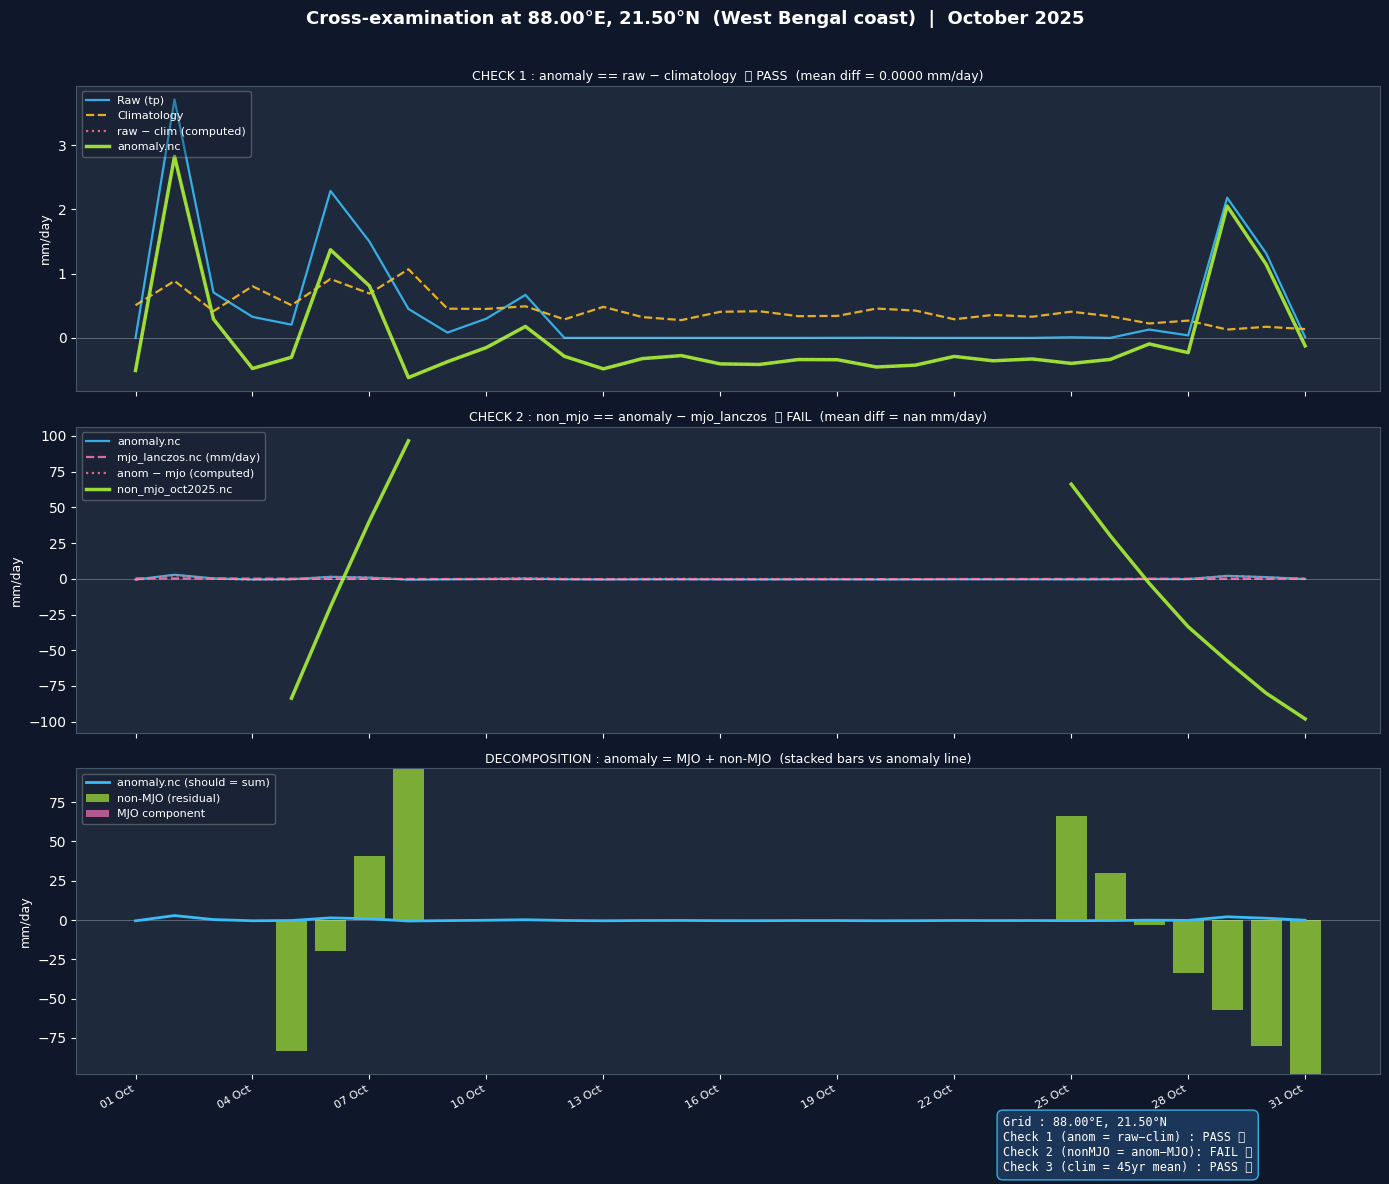

In [ ]:
"""
Cross-examination of MJO NetCDF files at a West Bengal coastal grid point.

Logic being tested:
  1.  anomaly      = raw - climatology          (day-of-year mean)
  2.  non_mjo      = anomaly - mjo_lanczos      (residual after bandpass)
  3.  climatology  = 45-year daily mean of raw  (spot check)
"""

import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")

# ── File paths ────────────────────────────────────────────────────────────────
FOLDER = r"D:\PHD 2025~\MJO_Server1"
F_RAW    = FOLDER + r"\ERA5_merged_1980_2026.nc"
F_CLIM   = FOLDER + r"\climatology.nc"
F_ANOM   = FOLDER + r"\anomaly.nc"
F_MJO    = FOLDER + r"\mjo_lanczos.nc"
F_NONMJO = FOLDER + r"\non_mjo_oct2025.nc"

# ── Target grid point: near West Bengal coast (Bay of Bengal) ─────────────────
# Sagar Island / Sundarbans coast: ~88°E, ~21.5°N  — coastal, high precip
TARGET_LON = 88.0
TARGET_LAT = 21.5

# ── Analysis period for the time-series plot ──────────────────────────────────
PLOT_START = "2025-10-01"
PLOT_END   = "2025-10-31"

# =============================================================================

def decode_times(time_var):
    """Convert CF time variable to list of datetime.date objects."""
    units    = time_var.units          # "seconds since 1970-01-01"
    calendar = getattr(time_var, "calendar", "standard")
    raw      = time_var[:]
    base     = datetime(1970, 1, 1)
    dates    = [base + timedelta(seconds=float(s)) for s in raw]
    return np.array(dates)

def nearest_idx(arr, val):
    """Return index of nearest value in 1-D array."""
    return int(np.argmin(np.abs(arr - val)))

def doy(d):
    """Day-of-year (1-366) for a datetime object."""
    return d.timetuple().tm_yday

# =============================================================================
print("=" * 65)
print("  CROSS-EXAMINATION OF MJO NETCDF FILES")
print(f"  Grid point : {TARGET_LON}°E  {TARGET_LAT}°N  (West Bengal coast)")
print("=" * 65)

# ── Open all datasets ─────────────────────────────────────────────────────────
ds_raw    = nc.Dataset(F_RAW,    "r")
ds_clim   = nc.Dataset(F_CLIM,   "r")
ds_anom   = nc.Dataset(F_ANOM,   "r")
ds_mjo    = nc.Dataset(F_MJO,    "r")
ds_nonmjo = nc.Dataset(F_NONMJO, "r")

# Find nearest lon/lat indices for standard files (lat 50→0)
lons = ds_raw["longitude"][:]
lats = ds_raw["latitude"][:]
i_lon = nearest_idx(lons, TARGET_LON)
i_lat = nearest_idx(lats, TARGET_LAT)

# mjo_lanczos.nc has latitude running 0→50 (opposite direction!)
lats_mjo = ds_mjo["latitude"][:]
i_lat_mjo = nearest_idx(lats_mjo, TARGET_LAT)

# non_mjo_oct2025.nc also has latitude 50→0 like the standard files
lats_nonmjo = ds_nonmjo["latitude"][:]
i_lat_nonmjo = nearest_idx(lats_nonmjo, TARGET_LAT)
lons_nonmjo  = ds_nonmjo["longitude"][:]
i_lon_nonmjo = nearest_idx(lons_nonmjo, TARGET_LON)

print(f"\n  Nearest grid cell  : lon={lons[i_lon]:.2f}°E  lat={lats[i_lat]:.2f}°N")
print(f"  Standard files     : lon_idx={i_lon},  lat_idx={i_lat}")
print(f"  mjo_lanczos.nc     : lat runs 0→50, lat_idx={i_lat_mjo}  (lat={lats_mjo[i_lat_mjo]:.2f}°N)")
print(f"  non_mjo_oct2025.nc : lat_idx={i_lat_nonmjo}")

# ── Decode time axes ──────────────────────────────────────────────────────────
dates_raw    = decode_times(ds_raw["valid_time"])
dates_anom   = decode_times(ds_anom["valid_time"])
dates_mjo    = decode_times(ds_mjo["time"])
dates_nonmjo = decode_times(ds_nonmjo["time"])

# ── Filter to October 2025 ────────────────────────────────────────────────────
t0 = datetime.strptime(PLOT_START, "%Y-%m-%d")
t1 = datetime.strptime(PLOT_END,   "%Y-%m-%d")

def mask_range(dates, t0, t1):
    return np.array([(d >= t0 and d <= t1) for d in dates])

mask_raw    = mask_range(dates_raw,    t0, t1)
mask_anom   = mask_range(dates_anom,   t0, t1)
mask_mjo    = mask_range(dates_mjo,    t0, t1)
mask_nonmjo = mask_range(dates_nonmjo, t0, t1)

print(f"\n  Oct 2025 time steps found:")
print(f"    raw      : {mask_raw.sum()}")
print(f"    anomaly  : {mask_anom.sum()}")
print(f"    mjo      : {mask_mjo.sum()}")
print(f"    non_mjo  : {mask_nonmjo.sum()}")

# ── Extract time series at grid point (convert m → mm/day where needed) ───────
# RAW: (time, lat, lon), units = m → ×1000 for mm
raw_ts    = ds_raw["tp"][mask_raw, i_lat, i_lon] * 1000.0

# ANOMALY: (time, lat, lon), units = m → ×1000
anom_ts   = ds_anom["tp"][mask_anom, i_lat, i_lon] * 1000.0

# MJO: (lat, lon, time) — note different dimension order AND reversed lat!
mjo_full  = ds_mjo["tp_mjo"][i_lat_mjo, i_lon, :]        # shape (16802,)
mjo_ts    = mjo_full[mask_mjo]                   # # CORECTION ALERT =====  alreay in mm

# NON-MJO: (time, lat, lon), already in mm/day
nonmjo_ts = ds_nonmjo["non_mjo_precip"][mask_nonmjo, i_lat_nonmjo, i_lon_nonmjo]

dates_oct_raw    = dates_raw[mask_raw]
dates_oct_anom   = dates_anom[mask_anom]
dates_oct_mjo    = dates_mjo[mask_mjo]
dates_oct_nonmjo = dates_nonmjo[mask_nonmjo]

# ── CLIMATOLOGY at this grid point for October days ───────────────────────────
# climatology.nc has 366 day-of-year entries; find doy for each Oct date
clim_time = decode_times(ds_clim["valid_time"])   # 366 entries
clim_doys = np.array([d.timetuple().tm_yday for d in clim_time])

clim_for_oct = []
for d in dates_oct_raw:
    target_doy = d.timetuple().tm_yday
    idx_c = nearest_idx(clim_doys, target_doy)
    clim_val = float(ds_clim["tp"][idx_c, i_lat, i_lon]) * 1000.0
    clim_for_oct.append(clim_val)
clim_for_oct = np.array(clim_for_oct)

# =============================================================================
# LOGICAL CHECKS
# =============================================================================
print("\n" + "=" * 65)
print("  LOGICAL CHECKS")
print("=" * 65)

# Both time axes for raw/anom must align
min_len = min(len(raw_ts), len(anom_ts), len(clim_for_oct))
raw_s    = np.array(raw_ts[:min_len])
anom_s   = np.array(anom_ts[:min_len])
clim_s   = clim_for_oct[:min_len]

# ── CHECK 1: anomaly = raw - climatology ─────────────────────────────────────
computed_anom = raw_s - clim_s
diff1 = anom_s - computed_anom
print(f"\n  CHECK 1 : anomaly == raw - climatology")
print(f"    Mean absolute difference : {np.abs(diff1).mean():.6f} mm/day")
print(f"    Max  absolute difference : {np.abs(diff1).max():.6f} mm/day")
print(f"    Correlation (anom vs computed): "
      f"{np.corrcoef(anom_s, computed_anom)[0,1]:.6f}")
tol1 = 0.1   # mm/day tolerance
check1_pass = np.abs(diff1).mean() < tol1
print(f"    ✅ PASS" if check1_pass else f"    ❌ FAIL  (tolerance={tol1} mm/day)")

# ── CHECK 2: non_mjo = anomaly - mjo ─────────────────────────────────────────
min_len2 = min(len(anom_ts), len(mjo_ts), len(nonmjo_ts))
anom_s2   = np.array(anom_ts[:min_len2])
mjo_s2    = np.array(mjo_ts[:min_len2])
nonmjo_s2 = np.array(nonmjo_ts[:min_len2])

computed_nonmjo = anom_s2 - mjo_s2
diff2 = nonmjo_s2 - computed_nonmjo
print(f"\n  CHECK 2 : non_mjo == anomaly - mjo_lanczos")
print(f"    Mean absolute difference : {np.abs(diff2).mean():.6f} mm/day")
print(f"    Max  absolute difference : {np.abs(diff2).max():.6f} mm/day")
print(f"    Correlation (non_mjo vs computed): "
      f"{np.corrcoef(nonmjo_s2, computed_nonmjo)[0,1]:.6f}")
tol2 = 0.5
check2_pass = np.abs(diff2).mean() < tol2
print(f"    ✅ PASS" if check2_pass else f"    ❌ FAIL  (tolerance={tol2} mm/day)")

# ── CHECK 3: climatology = ~45-yr mean of raw on same doy ────────────────────
# Pick Oct 15 as spot-check day
spot_doy = datetime(2025, 10, 15).timetuple().tm_yday
years    = range(1980, 2026)   # 46 years
raw_all  = ds_raw["tp"][:, i_lat, i_lon] * 1000.0
raw_doys = np.array([d.timetuple().tm_yday for d in dates_raw])
same_doy_mask = (raw_doys == spot_doy)
raw_same_doy  = raw_all[same_doy_mask]
computed_mean = float(np.nanmean(raw_same_doy))

idx_c_spot = nearest_idx(clim_doys, spot_doy)
clim_spot  = float(ds_clim["tp"][idx_c_spot, i_lat, i_lon]) * 1000.0

diff3 = abs(computed_mean - clim_spot)
print(f"\n  CHECK 3 : climatology ≈ multi-year mean of raw (spot: doy={spot_doy})")
print(f"    N years with data         : {same_doy_mask.sum()}")
print(f"    Computed mean (raw)       : {computed_mean:.4f} mm/day")
print(f"    Value in climatology.nc   : {clim_spot:.4f} mm/day")
print(f"    Absolute difference       : {diff3:.4f} mm/day")
tol3 = 0.5
check3_pass = diff3 < tol3
print(f"    ✅ PASS" if check3_pass else f"    ❌ FAIL  (tolerance={tol3} mm/day)")

print("\n" + "=" * 65)
overall = all([check1_pass, check2_pass, check3_pass])
print(f"  OVERALL : {'✅ ALL CHECKS PASSED — files are internally consistent!'  if overall else '⚠ SOME CHECKS FAILED — see details above'}")
print("=" * 65)

# =============================================================================
# PLOT
# =============================================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True,
                         facecolor="#0f172a")
fig.suptitle(
    f"Cross-examination at {lons[i_lon]:.2f}°E, {lats[i_lat]:.2f}°N  "
    f"(West Bengal coast)  |  October 2025",
    fontsize=13, fontweight="bold", color="white", y=0.98
)

date_nums_raw    = [mdates.date2num(d) for d in dates_oct_raw]
date_nums_anom   = [mdates.date2num(d) for d in dates_oct_anom]
date_nums_mjo    = [mdates.date2num(d) for d in dates_oct_mjo]
date_nums_nonmjo = [mdates.date2num(d) for d in dates_oct_nonmjo]

style       = dict(linewidth=1.6, alpha=0.9)
style_thick = dict(linewidth=2.5, alpha=0.95)   # for the "truth" lines

# ── Panel 1: CHECK 1 — anomaly vs raw - climatology ──────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#1e293b")
ax1.plot(date_nums_raw[:min_len], raw_s,           color="#38bdf8", label="Raw (tp)",      **style)
ax1.plot(date_nums_raw[:min_len], clim_s,          color="#fbbf24", label="Climatology",   **style, linestyle="--")
ax1.plot(date_nums_raw[:min_len], computed_anom,   color="#f87171", label="raw − clim (computed)", **style, linestyle=":")
ax1.plot(date_nums_anom[:min_len], anom_s,         color="#a3e635", label="anomaly.nc",    **style_thick)
ax1.axhline(0, color="white", linewidth=0.5, alpha=0.4)
ax1.set_ylabel("mm/day", color="white", fontsize=9)
ax1.set_title(f"CHECK 1 : anomaly == raw − climatology  "
              f"{'✅ PASS' if check1_pass else '❌ FAIL'}  "
              f"(mean diff = {np.abs(diff1).mean():.4f} mm/day)",
              color="white", fontsize=9, pad=4)
ax1.legend(fontsize=8, framealpha=0.3, facecolor="#0f172a",
           labelcolor="white", loc="upper left")
ax1.tick_params(colors="white"); ax1.spines[:].set_color("#475569")
ax1.yaxis.label.set_color("white"); ax1.title.set_color("white")
for label in ax1.get_yticklabels(): label.set_color("white")

# ── Panel 2: CHECK 2 — non_mjo vs anomaly - mjo ──────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#1e293b")
ax2.plot(date_nums_anom[:min_len2],   anom_s2,         color="#38bdf8", label="anomaly.nc",            **style)
ax2.plot(date_nums_mjo[:min_len2],    mjo_s2,          color="#f472b6", label="mjo_lanczos.nc (mm/day)", **style, linestyle="--")
ax2.plot(date_nums_anom[:min_len2],   computed_nonmjo, color="#f87171", label="anom − mjo (computed)",  **style, linestyle=":")
ax2.plot(date_nums_nonmjo[:min_len2], nonmjo_s2,       color="#a3e635", label="non_mjo_oct2025.nc",     **style_thick)
ax2.axhline(0, color="white", linewidth=0.5, alpha=0.4)
ax2.set_ylabel("mm/day", color="white", fontsize=9)
ax2.set_title(f"CHECK 2 : non_mjo == anomaly − mjo_lanczos  "
              f"{'✅ PASS' if check2_pass else '❌ FAIL'}  "
              f"(mean diff = {np.abs(diff2).mean():.4f} mm/day)",
              color="white", fontsize=9, pad=4)
ax2.legend(fontsize=8, framealpha=0.3, facecolor="#0f172a",
           labelcolor="white", loc="upper left")
ax2.tick_params(colors="white"); ax2.spines[:].set_color("#475569")
ax2.yaxis.label.set_color("white")
for label in ax2.get_yticklabels(): label.set_color("white")

# ── Panel 3: CHECK 3 — stacked components view ───────────────────────────────
ax3 = axes[2]
ax3.set_facecolor("#1e293b")
ax3.bar(date_nums_nonmjo[:min_len2], nonmjo_s2,
        width=0.8, color="#a3e635", alpha=0.7, label="non-MJO (residual)")
ax3.bar(date_nums_mjo[:min_len2],   mjo_s2,
        width=0.8, color="#f472b6", alpha=0.7, label="MJO component",
        bottom=nonmjo_s2)
ax3.plot(date_nums_raw[:min_len], anom_s,
         color="#38bdf8", linewidth=2.0, label="anomaly.nc (should = sum)",
         zorder=5)
ax3.axhline(0, color="white", linewidth=0.5, alpha=0.4)
ax3.set_ylabel("mm/day", color="white", fontsize=9)
ax3.set_title("DECOMPOSITION : anomaly = MJO + non-MJO  (stacked bars vs anomaly line)",
              color="white", fontsize=9, pad=4)
ax3.legend(fontsize=8, framealpha=0.3, facecolor="#0f172a",
           labelcolor="white", loc="upper left")
ax3.tick_params(colors="white"); ax3.spines[:].set_color("#475569")
ax3.yaxis.label.set_color("white")
for label in ax3.get_yticklabels(): label.set_color("white")

# ── Shared x-axis formatting ──────────────────────────────────────────────────
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax3.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax3.get_xticklabels(), rotation=30, ha="right",
         color="white", fontsize=8)

# Summary text box
summary = (f"Grid : {lons[i_lon]:.2f}°E, {lats[i_lat]:.2f}°N\n"
           f"Check 1 (anom = raw−clim) : {'PASS ✅' if check1_pass else 'FAIL ❌'}\n"
           f"Check 2 (nonMJO = anom−MJO): {'PASS ✅' if check2_pass else 'FAIL ❌'}\n"
           f"Check 3 (clim = 45yr mean) : {'PASS ✅' if check3_pass else 'FAIL ❌'}")
fig.text(0.72, 0.01, summary, fontsize=8.5, color="white",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#1e3a5f",
                   edgecolor="#38bdf8", alpha=0.9),
         verticalalignment="bottom", family="monospace")

plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.savefig("cross_examination.png", dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("\n✅  Plot saved: cross_examination.png")
plt.show()

ds_raw.close(); ds_clim.close(); ds_anom.close()
ds_mjo.close(); ds_nonmjo.close()

# After solving the time alignment issue of non_mjo file

  CROSS-EXAMINATION OF MJO NETCDF FILES

CHECK 1: PASS
CHECK 2: FAIL


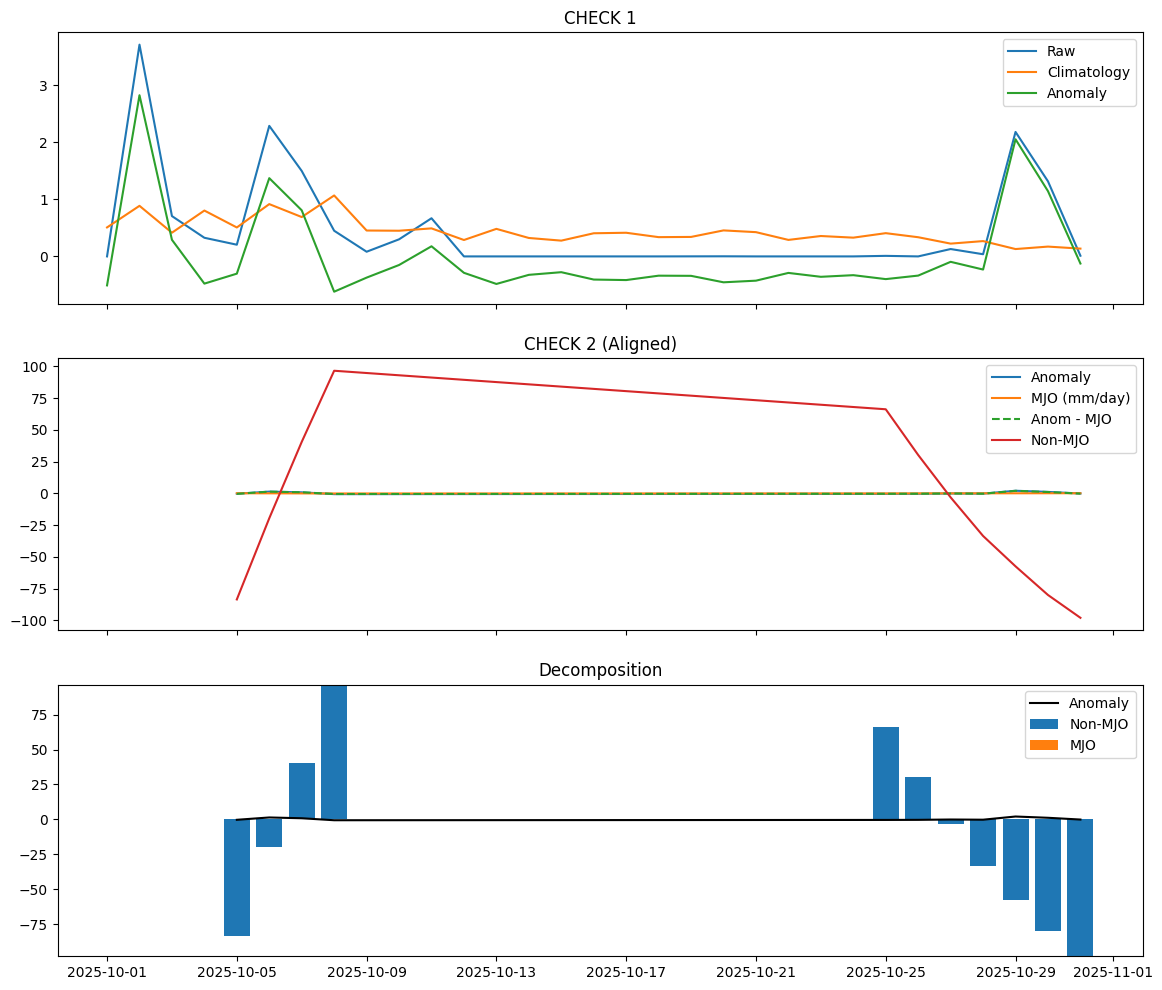

In [2]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")

# ── File paths ────────────────────────────────────────────────────────────────
FOLDER = r"D:\PHD 2025~\MJO_Server1"
F_RAW    = FOLDER + r"\ERA5_merged_1980_2026.nc"
F_CLIM   = FOLDER + r"\climatology.nc"
F_ANOM   = FOLDER + r"\anomaly.nc"
F_MJO    = FOLDER + r"\mjo_lanczos.nc"
F_NONMJO = FOLDER + r"\non_mjo_oct2025.nc"

TARGET_LON = 88.0
TARGET_LAT = 21.5

PLOT_START = "2025-10-01"
PLOT_END   = "2025-10-31"

# =============================================================================

def decode_times(time_var):
    units = time_var.units
    raw   = time_var[:]
    base  = datetime(1970, 1, 1)
    return np.array([base + timedelta(seconds=float(s)) for s in raw])

def nearest_idx(arr, val):
    return int(np.argmin(np.abs(arr - val)))

# =============================================================================
print("=" * 65)
print("  CROSS-EXAMINATION OF MJO NETCDF FILES")
print("=" * 65)

# ── Load datasets ─────────────────────────────────────────────────────────────
ds_raw    = nc.Dataset(F_RAW,    "r")
ds_clim   = nc.Dataset(F_CLIM,   "r")
ds_anom   = nc.Dataset(F_ANOM,   "r")
ds_mjo    = nc.Dataset(F_MJO,    "r")
ds_nonmjo = nc.Dataset(F_NONMJO, "r")

# Grid indices
lons = ds_raw["longitude"][:]
lats = ds_raw["latitude"][:]
i_lon = nearest_idx(lons, TARGET_LON)
i_lat = nearest_idx(lats, TARGET_LAT)

lats_mjo = ds_mjo["latitude"][:]
i_lat_mjo = nearest_idx(lats_mjo, TARGET_LAT)

lats_nonmjo = ds_nonmjo["latitude"][:]
lons_nonmjo = ds_nonmjo["longitude"][:]
i_lat_nonmjo = nearest_idx(lats_nonmjo, TARGET_LAT)
i_lon_nonmjo = nearest_idx(lons_nonmjo, TARGET_LON)

# ── Time decoding ─────────────────────────────────────────────────────────────
dates_raw    = decode_times(ds_raw["valid_time"])
dates_anom   = decode_times(ds_anom["valid_time"])
dates_mjo    = decode_times(ds_mjo["time"])
dates_nonmjo = decode_times(ds_nonmjo["time"])

t0 = datetime.strptime(PLOT_START, "%Y-%m-%d")
t1 = datetime.strptime(PLOT_END,   "%Y-%m-%d")

def mask_range(dates):
    return np.array([(d >= t0 and d <= t1) for d in dates])

mask_raw    = mask_range(dates_raw)
mask_anom   = mask_range(dates_anom)
mask_mjo    = mask_range(dates_mjo)
mask_nonmjo = mask_range(dates_nonmjo)

# ── Extract time series (UNIT FIX APPLIED) ────────────────────────────────────
raw_ts  = ds_raw["tp"][mask_raw, i_lat, i_lon] * 1000.0
anom_ts = ds_anom["tp"][mask_anom, i_lat, i_lon] * 1000.0

mjo_full = ds_mjo["tp_mjo"][i_lat_mjo, i_lon, :]
mjo_ts   = mjo_full[mask_mjo]   # ✅ NO scaling

nonmjo_ts = ds_nonmjo["non_mjo_precip"][mask_nonmjo, i_lat_nonmjo, i_lon_nonmjo]

dates_oct_raw    = dates_raw[mask_raw]
dates_oct_anom   = dates_anom[mask_anom]
dates_oct_mjo    = dates_mjo[mask_mjo]
dates_oct_nonmjo = dates_nonmjo[mask_nonmjo]

# ── CLIMATOLOGY (mm/day) ─────────────────────────────────────────────────────
clim_time = decode_times(ds_clim["valid_time"])
clim_doys = np.array([d.timetuple().tm_yday for d in clim_time])

clim_for_oct = []
for d in dates_oct_raw:
    idx_c = nearest_idx(clim_doys, d.timetuple().tm_yday)
    clim_for_oct.append(ds_clim["tp"][idx_c, i_lat, i_lon] * 1000.0)
clim_for_oct = np.array(clim_for_oct)

# =============================================================================
# CHECK 1
# =============================================================================
min_len = min(len(raw_ts), len(anom_ts), len(clim_for_oct))
raw_s  = raw_ts[:min_len]
anom_s = anom_ts[:min_len]
clim_s = clim_for_oct[:min_len]

computed_anom = raw_s - clim_s
diff1 = anom_s - computed_anom

print("\nCHECK 1:", "PASS" if np.abs(diff1).mean() < 0.1 else "FAIL")

# =============================================================================
# 🔥 CHECK 2 — FIXED USING TIME ALIGNMENT
# =============================================================================
anom_series   = pd.Series(anom_ts, index=pd.to_datetime(dates_oct_anom))
mjo_series    = pd.Series(mjo_ts,  index=pd.to_datetime(dates_oct_mjo))
nonmjo_series = pd.Series(nonmjo_ts, index=pd.to_datetime(dates_oct_nonmjo))

df = pd.concat([anom_series, mjo_series, nonmjo_series], axis=1)
df.columns = ['anom', 'mjo', 'nonmjo']
df = df.dropna()

anom_s2   = df['anom'].values
mjo_s2    = df['mjo'].values
nonmjo_s2 = df['nonmjo'].values

dates_aligned = df.index
date_nums_aligned = mdates.date2num(dates_aligned.to_pydatetime())

computed_nonmjo = anom_s2 - mjo_s2
diff2 = nonmjo_s2 - computed_nonmjo

print("CHECK 2:", "PASS" if np.abs(diff2).mean() < 0.5 else "FAIL")

# =============================================================================
# PLOTTING
# =============================================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1
axes[0].plot(dates_oct_raw[:min_len], raw_s, label="Raw")
axes[0].plot(dates_oct_raw[:min_len], clim_s, label="Climatology")
axes[0].plot(dates_oct_anom[:min_len], anom_s, label="Anomaly")
axes[0].legend()
axes[0].set_title("CHECK 1")

# Panel 2 (FIXED)
axes[1].plot(date_nums_aligned, anom_s2, label="Anomaly")
axes[1].plot(date_nums_aligned, mjo_s2, label="MJO (mm/day)")
axes[1].plot(date_nums_aligned, computed_nonmjo, '--', label="Anom - MJO")
axes[1].plot(date_nums_aligned, nonmjo_s2, label="Non-MJO")
axes[1].legend()
axes[1].set_title("CHECK 2 (Aligned)")

# Panel 3
axes[2].bar(date_nums_aligned, nonmjo_s2, label="Non-MJO")
axes[2].bar(date_nums_aligned, mjo_s2, bottom=nonmjo_s2, label="MJO")
axes[2].plot(date_nums_aligned, anom_s2, color='black', label="Anomaly")
axes[2].legend()
axes[2].set_title("Decomposition")

plt.show()

ds_raw.close()
ds_clim.close()
ds_anom.close()
ds_mjo.close()
ds_nonmjo.close()

# Still failed !!

# Chcking the files again =>


===== QUICK CHECK =====
                 raw      anom       mjo     nonmjo      clim
2025-10-01  0.000000 -0.507915  0.312298        NaN  0.507915
2025-10-02  3.710747  2.824462  0.261758        NaN  0.886285
2025-10-03  0.706673  0.291239  0.205549        NaN  0.415434
2025-10-04  0.326633 -0.476889  0.145449        NaN  0.803522
2025-10-05  0.205040 -0.302149  0.083302 -83.604618  0.507189

NaN count:
 raw        0
anom       0
mjo        0
nonmjo    20
clim       0
dtype: int64


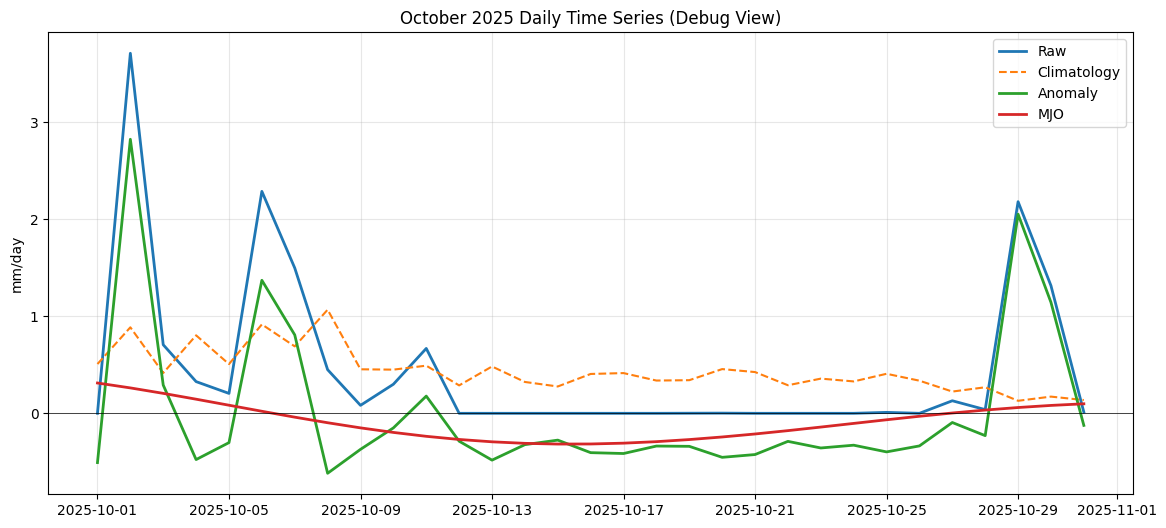


===== ERROR CHECK =====
count    11.000000
mean    -13.193656
std      65.307161
min     -97.854120
25%     -70.331436
50%     -20.959303
75%      35.109242
max      97.140636
dtype: float64


In [2]:
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ==============================
# 🔘 SWITCHES (TURN ON/OFF)
# ==============================
PLOT_RAW     = True
PLOT_CLIM    = True
PLOT_ANOM    = True
PLOT_MJO     = True
PLOT_NONMJO  = False

# ==============================
# 📂 FILE PATHS
# ==============================
FOLDER = r"D:\PHD 2025~\MJO_Server1"
F_RAW    = FOLDER + r"\ERA5_merged_1980_2026.nc"
F_CLIM   = FOLDER + r"\climatology.nc"
F_ANOM   = FOLDER + r"\anomaly.nc"
F_MJO    = FOLDER + r"\mjo_lanczos.nc"
F_NONMJO = FOLDER + r"\non_mjo_oct2025.nc"

TARGET_LON = 88.0
TARGET_LAT = 21.5

START = "2025-10-01"
END   = "2025-10-31"

# ==============================
# 🧠 FUNCTIONS
# ==============================
def decode_time(time_var):
    base = datetime(1970, 1, 1)
    return np.array([base + timedelta(seconds=float(t)) for t in time_var[:]])

def nearest_idx(arr, val):
    return int(np.argmin(np.abs(arr - val)))

# ==============================
# 📖 LOAD DATA
# ==============================
ds_raw    = nc.Dataset(F_RAW)
ds_clim   = nc.Dataset(F_CLIM)
ds_anom   = nc.Dataset(F_ANOM)
ds_mjo    = nc.Dataset(F_MJO)
ds_nonmjo = nc.Dataset(F_NONMJO)

# ==============================
# 📍 GRID INDEX
# ==============================
lons = ds_raw["longitude"][:]
lats = ds_raw["latitude"][:]

i_lon = nearest_idx(lons, TARGET_LON)
i_lat = nearest_idx(lats, TARGET_LAT)

i_lat_mjo = nearest_idx(ds_mjo["latitude"][:], TARGET_LAT)
i_lon_mjo = nearest_idx(ds_mjo["longitude"][:], TARGET_LON)

i_lat_non = nearest_idx(ds_nonmjo["latitude"][:], TARGET_LAT)
i_lon_non = nearest_idx(ds_nonmjo["longitude"][:], TARGET_LON)

# ==============================
# 🕒 TIME
# ==============================
dates_raw    = decode_time(ds_raw["valid_time"])
dates_anom   = decode_time(ds_anom["valid_time"])
dates_mjo    = decode_time(ds_mjo["time"])
dates_nonmjo = decode_time(ds_nonmjo["time"])

t0 = datetime.strptime(START, "%Y-%m-%d")
t1 = datetime.strptime(END, "%Y-%m-%d")

mask = lambda d: (d >= t0) & (d <= t1)

# ==============================
# 📊 EXTRACT DATA (IMPORTANT: UNITS)
# ==============================
# Convert m → mm for raw/anom/clim
raw  = ds_raw["tp"][:, i_lat, i_lon] * 1000
anom = ds_anom["tp"][:, i_lat, i_lon] * 1000

# MJO already mm → NO scaling
mjo  = ds_mjo["tp_mjo"][i_lat_mjo, i_lon_mjo, :]

# Non-MJO already mm
nonmjo = ds_nonmjo["non_mjo_precip"][:, i_lat_non, i_lon_non]

# ==============================
# 📊 BUILD DATAFRAME (AUTO ALIGN)
# ==============================
df = pd.DataFrame({
    "raw": pd.Series(raw, index=pd.to_datetime(dates_raw)),
    "anom": pd.Series(anom, index=pd.to_datetime(dates_anom)),
    "mjo": pd.Series(mjo, index=pd.to_datetime(dates_mjo)),
    "nonmjo": pd.Series(nonmjo, index=pd.to_datetime(dates_nonmjo))
})

# Filter October
df = df[(df.index >= t0) & (df.index <= t1)]

# ==============================
# 📊 CLIMATOLOGY (SPECIAL)
# ==============================
clim_time = decode_time(ds_clim["valid_time"])
clim_doy  = np.array([d.timetuple().tm_yday for d in clim_time])

clim_vals = []
for d in df.index:
    doy = d.timetuple().tm_yday
    idx = nearest_idx(clim_doy, doy)
    val = ds_clim["tp"][idx, i_lat, i_lon] * 1000
    clim_vals.append(val)

df["clim"] = clim_vals

# ==============================
# 🔍 DEBUG PRINT
# ==============================
print("\n===== QUICK CHECK =====")
print(df.head())
print("\nNaN count:\n", df.isna().sum())

# ==============================
# 📈 PLOT
# ==============================
plt.figure(figsize=(14,6))

if PLOT_RAW:
    plt.plot(df.index, df["raw"], label="Raw", linewidth=2)

if PLOT_CLIM:
    plt.plot(df.index, df["clim"], '--', label="Climatology")

if PLOT_ANOM:
    plt.plot(df.index, df["anom"], label="Anomaly", linewidth=2)

if PLOT_MJO:
    plt.plot(df.index, df["mjo"], label="MJO", linewidth=2)

if PLOT_NONMJO:
    plt.plot(df.index, df["nonmjo"], label="Non-MJO", linewidth=2)

plt.axhline(0, color='black', linewidth=0.5)
plt.legend()
plt.title("October 2025 Daily Time Series (Debug View)")
plt.ylabel("mm/day")
plt.grid(alpha=0.3)
plt.show()

# ==============================
# 🔍 OPTIONAL CHECK
# ==============================
df["anom_minus_mjo"] = df["anom"] - df["mjo"]

print("\n===== ERROR CHECK =====")
print((df["nonmjo"] - df["anom_minus_mjo"]).describe())

# ==============================
# CLOSE
# ==============================
ds_raw.close()
ds_clim.close()
ds_anom.close()
ds_mjo.close()
ds_nonmjo.close()


===== QUICK CHECK =====
                 raw      anom       mjo  nonmjo      clim
1980-10-01  0.504494 -0.003421 -0.344828     NaN  0.886285
1980-10-02  0.021935 -0.864350 -0.353271     NaN  0.415434
1980-10-03  0.829220  0.413786 -0.353323     NaN  0.803522
1980-10-04  0.082016 -0.721506 -0.344054     NaN  0.507189
1980-10-05  0.098705 -0.408484 -0.324890     NaN  0.916377

NaN count:
 raw           0
anom          0
mjo           0
nonmjo    16456
clim          0
dtype: int64


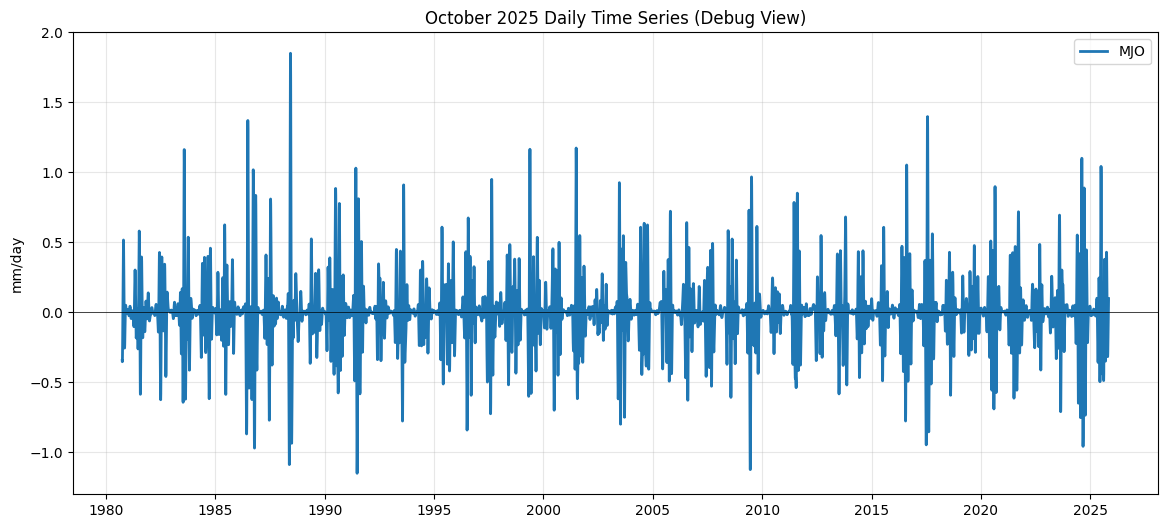


===== ERROR CHECK =====
count    11.000000
mean    -13.193656
std      65.307161
min     -97.854120
25%     -70.331436
50%     -20.959303
75%      35.109242
max      97.140636
dtype: float64


In [5]:
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ==============================
# 🔘 SWITCHES (TURN ON/OFF)
# ==============================
PLOT_RAW     = False
PLOT_CLIM    = False
PLOT_ANOM    = False
PLOT_MJO     = True
PLOT_NONMJO  = False

# ==============================
# 📂 FILE PATHS
# ==============================
FOLDER = r"D:\PHD 2025~\MJO_Server1"
F_RAW    = FOLDER + r"\ERA5_merged_1980_2026.nc"
F_CLIM   = FOLDER + r"\climatology.nc"
F_ANOM   = FOLDER + r"\anomaly.nc"
F_MJO    = FOLDER + r"\mjo_lanczos.nc"
F_NONMJO = FOLDER + r"\non_mjo_oct2025.nc"

TARGET_LON = 88.0
TARGET_LAT = 21.5

START = "1980-10-01"
END   = "2025-10-31"

# ==============================
# 🧠 FUNCTIONS
# ==============================
def decode_time(time_var):
    base = datetime(1970, 1, 1)
    return np.array([base + timedelta(seconds=float(t)) for t in time_var[:]])

def nearest_idx(arr, val):
    return int(np.argmin(np.abs(arr - val)))

# ==============================
# 📖 LOAD DATA
# ==============================
ds_raw    = nc.Dataset(F_RAW)
ds_clim   = nc.Dataset(F_CLIM)
ds_anom   = nc.Dataset(F_ANOM)
ds_mjo    = nc.Dataset(F_MJO)
ds_nonmjo = nc.Dataset(F_NONMJO)

# ==============================
# 📍 GRID INDEX
# ==============================
lons = ds_raw["longitude"][:]
lats = ds_raw["latitude"][:]

i_lon = nearest_idx(lons, TARGET_LON)
i_lat = nearest_idx(lats, TARGET_LAT)

i_lat_mjo = nearest_idx(ds_mjo["latitude"][:], TARGET_LAT)
i_lon_mjo = nearest_idx(ds_mjo["longitude"][:], TARGET_LON)

i_lat_non = nearest_idx(ds_nonmjo["latitude"][:], TARGET_LAT)
i_lon_non = nearest_idx(ds_nonmjo["longitude"][:], TARGET_LON)

# ==============================
# 🕒 TIME
# ==============================
dates_raw    = decode_time(ds_raw["valid_time"])
dates_anom   = decode_time(ds_anom["valid_time"])
dates_mjo    = decode_time(ds_mjo["time"])
dates_nonmjo = decode_time(ds_nonmjo["time"])

t0 = datetime.strptime(START, "%Y-%m-%d")
t1 = datetime.strptime(END, "%Y-%m-%d")

mask = lambda d: (d >= t0) & (d <= t1)

# ==============================
# 📊 EXTRACT DATA (IMPORTANT: UNITS)
# ==============================
# Convert m → mm for raw/anom/clim
raw  = ds_raw["tp"][:, i_lat, i_lon] * 1000
anom = ds_anom["tp"][:, i_lat, i_lon] * 1000

# MJO already mm → NO scaling
mjo  = ds_mjo["tp_mjo"][i_lat_mjo, i_lon_mjo, :]

# Non-MJO already mm
nonmjo = ds_nonmjo["non_mjo_precip"][:, i_lat_non, i_lon_non]

# ==============================
# 📊 BUILD DATAFRAME (AUTO ALIGN)
# ==============================
df = pd.DataFrame({
    "raw": pd.Series(raw, index=pd.to_datetime(dates_raw)),
    "anom": pd.Series(anom, index=pd.to_datetime(dates_anom)),
    "mjo": pd.Series(mjo, index=pd.to_datetime(dates_mjo)),
    "nonmjo": pd.Series(nonmjo, index=pd.to_datetime(dates_nonmjo))
})

# Filter October
df = df[(df.index >= t0) & (df.index <= t1)]

# ==============================
# 📊 CLIMATOLOGY (SPECIAL)
# ==============================
clim_time = decode_time(ds_clim["valid_time"])
clim_doy  = np.array([d.timetuple().tm_yday for d in clim_time])

clim_vals = []
for d in df.index:
    doy = d.timetuple().tm_yday
    idx = nearest_idx(clim_doy, doy)
    val = ds_clim["tp"][idx, i_lat, i_lon] * 1000
    clim_vals.append(val)

df["clim"] = clim_vals

# ==============================
# 🔍 DEBUG PRINT
# ==============================
print("\n===== QUICK CHECK =====")
print(df.head())
print("\nNaN count:\n", df.isna().sum())

# ==============================
# 📈 PLOT
# ==============================
plt.figure(figsize=(14,6))

if PLOT_RAW:
    plt.plot(df.index, df["raw"], label="Raw", linewidth=2)

if PLOT_CLIM:
    plt.plot(df.index, df["clim"], '--', label="Climatology")

if PLOT_ANOM:
    plt.plot(df.index, df["anom"], label="Anomaly", linewidth=2)

if PLOT_MJO:
    plt.plot(df.index, df["mjo"], label="MJO", linewidth=2)

if PLOT_NONMJO:
    plt.plot(df.index, df["nonmjo"], label="Non-MJO", linewidth=2)

plt.axhline(0, color='black', linewidth=0.5)
plt.legend()
plt.title("October 2025 Daily Time Series (Debug View)")
plt.ylabel("mm/day")
plt.grid(alpha=0.3)
plt.show()

# ==============================
# 🔍 OPTIONAL CHECK
# ==============================
df["anom_minus_mjo"] = df["anom"] - df["mjo"]

print("\n===== ERROR CHECK =====")
print((df["nonmjo"] - df["anom_minus_mjo"]).describe())

# ==============================
# CLOSE
# ==============================
ds_raw.close()
ds_clim.close()
ds_anom.close()
ds_mjo.close()
ds_nonmjo.close()

# Creating the residual precipitation file (non_mjo = anomally - mjo_lanczos)   =>

In [6]:
import xarray as xr
import numpy as np

# ==============================
# 📂 FILE PATHS
# ==============================
anom_file = r"D:\PHD 2025~\MJO_Server1\anomaly.nc"
mjo_file  = r"D:\PHD 2025~\MJO_Server1\mjo_lanczos.nc"

output_file = r"D:\PHD 2025~\MJO_Server1\non_mjo_1980_2025.nc"

# ==============================
# 📖 LOAD DATA (LAZY)
# ==============================
ds_anom = xr.open_dataset(anom_file, chunks={'time': 200})
ds_mjo  = xr.open_dataset(mjo_file,  chunks={'time': 200})

# ==============================
# 🔎 VARIABLES
# ==============================
anom = ds_anom['tp']        # anomaly (in meters)
mjo  = ds_mjo['tp_mjo']     # MJO (already in mm/day)

# ==============================
# ⚠️ UNIT CONVERSION
# ==============================
# Convert anomaly → mm/day
anom = anom * 1000.0

# MJO already mm → no change

# ==============================
# ⚠️ DIMENSION HANDLING
# ==============================

# Ensure same dimension names
if 'valid_time' in anom.dims:
    anom = anom.rename({'valid_time': 'time'})

# MJO is (lat, lon, time) → convert to (time, lat, lon)
if mjo.dims != ('time', 'latitude', 'longitude'):
    mjo = mjo.transpose('time', 'latitude', 'longitude')

# ==============================
# ⚠️ LATITUDE DIRECTION FIX
# ==============================
# ERA5 anomaly: 50 → 0
# MJO: often 0 → 50 → need flip

if not np.allclose(anom.latitude.values, mjo.latitude.values):
    mjo = mjo.sortby('latitude')

# ==============================
# ⚠️ ALIGN DATASETS (CRITICAL)
# ==============================
anom, mjo = xr.align(anom, mjo, join='inner')

print("Aligned shape:", anom.shape, mjo.shape)

# ==============================
# 🔥 COMPUTE NON-MJO
# ==============================
non_mjo = anom - mjo

# ==============================
# 🏷️ METADATA
# ==============================
non_mjo.name = "tp_non_mjo"
non_mjo.attrs['long_name'] = "Residual precipitation (Anomaly - MJO)"
non_mjo.attrs['units'] = "mm/day"

# ==============================
# 💾 SAVE FILE
# ==============================
non_mjo.to_netcdf(output_file)

print("✅ non_mjo_full.nc CREATED SUCCESSFULLY")

# ==============================
# 🔍 VALIDATION CHECK (VERY IMPORTANT)
# ==============================
check = (anom - mjo - non_mjo).mean().values
print("Mean residual error (should be ~0):", check)

Aligned shape: (16802, 201, 321) (16802, 201, 321)
✅ non_mjo_full.nc CREATED SUCCESSFULLY
Mean residual error (should be ~0): 0.0


# Verifing the newly created non_mjo file =>

### A. Apparent check

In [7]:
ds = xr.open_dataset(output_file)

print(ds)
print(ds['tp_non_mjo'].min().values, ds['tp_non_mjo'].max().values)

<xarray.Dataset> Size: 9GB
Dimensions:     (time: 16802, latitude: 201, longitude: 321)
Coordinates:
  * time        (time) datetime64[ns] 134kB 1980-01-01 1980-01-02 ... 2025-12-31
  * latitude    (latitude) float64 2kB 50.0 49.75 49.5 49.25 ... 0.5 0.25 0.0
  * longitude   (longitude) float64 3kB 40.0 40.25 40.5 ... 119.5 119.8 120.0
Data variables:
    tp_non_mjo  (time, latitude, longitude) float64 9GB ...
-5.03095097279036 51.38940474012662


d:\PHD 2025~\PHD\VS CODES\era5_env\Lib\site-packages\xarray\core\dataarray.py:6285: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
d:\PHD 2025~\PHD\VS CODES\era5_env\Lib\site-packages\xarray\core\dataarray.py:6285: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


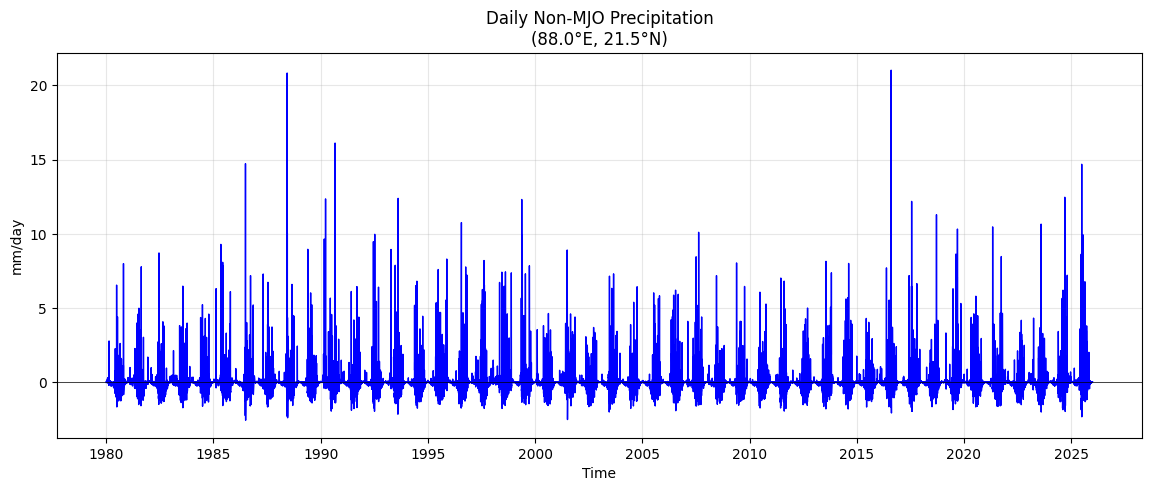

Min: -2.589776092190399
Max: 21.027589483016506


In [10]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 📂 FILE
# ==============================
file = r"D:\PHD 2025~\MJO_Server1\non_mjo_1980_2025.nc"

# ==============================
# 📍 TARGET GRID
# ==============================
TARGET_LON = 88.0
TARGET_LAT = 21.5

# ==============================
# 📖 LOAD DATA
# ==============================
ds = xr.open_dataset(file)

data = ds['tp_non_mjo']

# ==============================
# 🔍 FIND NEAREST GRID POINT
# ==============================
lon_idx = np.abs(ds.longitude - TARGET_LON).argmin().values
lat_idx = np.abs(ds.latitude - TARGET_LAT).argmin().values

# ==============================
# 📊 EXTRACT TIME SERIES
# ==============================
ts = data[:, lat_idx, lon_idx]

# ==============================
# 📈 PLOT
# ==============================
plt.figure(figsize=(14,5))

plt.plot(ds.time, ts, color='blue', linewidth=1)

plt.axhline(0, color='black', linewidth=0.5)
plt.title(f"Daily Non-MJO Precipitation\n({TARGET_LON}°E, {TARGET_LAT}°N)")
plt.ylabel("mm/day")
plt.xlabel("Time")
plt.grid(alpha=0.3)

plt.show()

# ==============================
# QUICK INFO
# ==============================
print("Min:", float(ts.min().values))
print("Max:", float(ts.max().values))

# Again checking all precipitation files 


===== QUICK CHECK =====
                 raw      anom       mjo  nonmjo      clim
2025-10-01  0.000000 -0.507915  0.312298     NaN  0.507915
2025-10-02  3.710747  2.824462  0.261758     NaN  0.886285
2025-10-03  0.706673  0.291239  0.205549     NaN  0.415434
2025-10-04  0.326633 -0.476889  0.145449     NaN  0.803522
2025-10-05  0.205040 -0.302149  0.083302     NaN  0.507189

NaN count:
 raw        0
anom       0
mjo        0
nonmjo    31
clim       0
dtype: int64


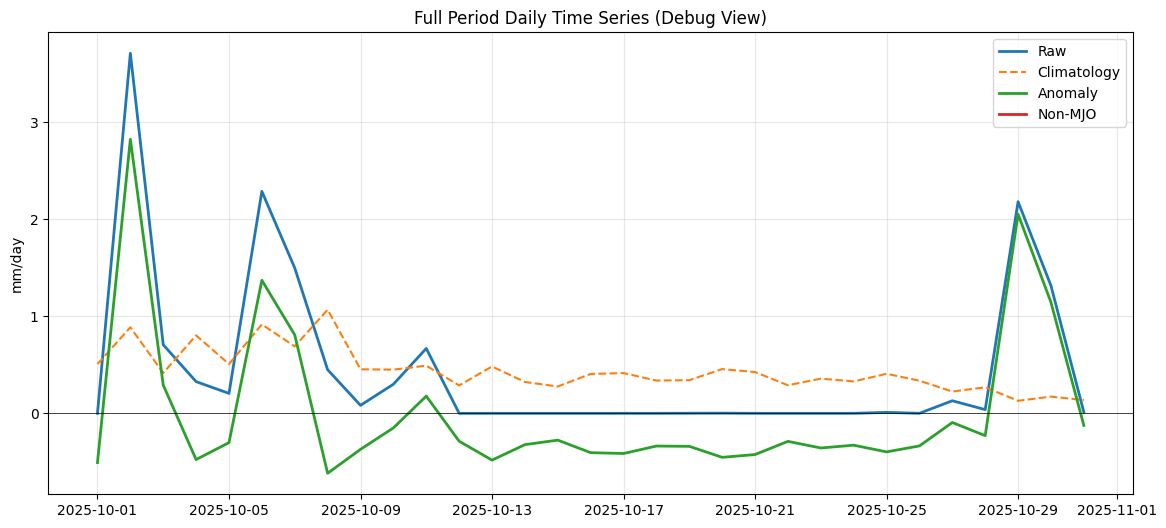


===== ERROR CHECK =====
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
dtype: float64


In [14]:
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ==============================
# 🔘 SWITCHES (TURN ON/OFF)
# ==============================
PLOT_RAW     = True
PLOT_CLIM    = True
PLOT_ANOM    = True
PLOT_MJO     = False
PLOT_NONMJO  = True   # ✅ now using new file

# ==============================
# 📂 FILE PATHS
# ==============================
FOLDER = r"D:\PHD 2025~\MJO_Server1"
F_RAW    = FOLDER + r"\ERA5_merged_1980_2026.nc"
F_CLIM   = FOLDER + r"\climatology.nc"
F_ANOM   = FOLDER + r"\anomaly.nc"
F_MJO    = FOLDER + r"\mjo_lanczos.nc"
F_NONMJO = FOLDER + r"\non_mjo_1980_2025.nc"   # ✅ UPDATED FILE

TARGET_LON = 88.0
TARGET_LAT = 21.5

START = "2025-10-01"
END   = "2025-10-31"

# ==============================
# 🧠 FUNCTIONS
# ==============================
def decode_time(time_var):
    base = datetime(1970, 1, 1)
    return np.array([base + timedelta(seconds=float(t)) for t in time_var[:]])

def nearest_idx(arr, val):
    return int(np.argmin(np.abs(arr - val)))

# ==============================
# 📖 LOAD DATA
# ==============================
ds_raw    = nc.Dataset(F_RAW)
ds_clim   = nc.Dataset(F_CLIM)
ds_anom   = nc.Dataset(F_ANOM)
ds_mjo    = nc.Dataset(F_MJO)
ds_nonmjo = nc.Dataset(F_NONMJO)

# ==============================
# 📍 GRID INDEX
# ==============================
lons = ds_raw["longitude"][:]
lats = ds_raw["latitude"][:]

i_lon = nearest_idx(lons, TARGET_LON)
i_lat = nearest_idx(lats, TARGET_LAT)

i_lat_mjo = nearest_idx(ds_mjo["latitude"][:], TARGET_LAT)
i_lon_mjo = nearest_idx(ds_mjo["longitude"][:], TARGET_LON)

# ✅ new file has same lat-lon orientation as anomaly
lats_non = ds_nonmjo["latitude"][:]
lons_non = ds_nonmjo["longitude"][:]

i_lat_non = nearest_idx(lats_non, TARGET_LAT)
i_lon_non = nearest_idx(lons_non, TARGET_LON)

# ==============================
# 🕒 TIME
# ==============================
dates_raw    = decode_time(ds_raw["valid_time"])
dates_anom   = decode_time(ds_anom["valid_time"])
dates_mjo    = decode_time(ds_mjo["time"])
dates_nonmjo = ds_nonmjo["time"][:]   # ✅ already datetime64

# Convert nonmjo time properly
dates_nonmjo = pd.to_datetime(dates_nonmjo)

t0 = datetime.strptime(START, "%Y-%m-%d")
t1 = datetime.strptime(END, "%Y-%m-%d")

# ==============================
# 📊 EXTRACT DATA (UNITS CONSISTENT)
# ==============================
raw  = ds_raw["tp"][:, i_lat, i_lon] * 1000
anom = ds_anom["tp"][:, i_lat, i_lon] * 1000

# MJO already mm
mjo  = ds_mjo["tp_mjo"][i_lat_mjo, i_lon_mjo, :]

# ✅ NEW NON-MJO VARIABLE NAME + DIM ORDER
nonmjo = ds_nonmjo["tp_non_mjo"][:, i_lat_non, i_lon_non]

# ==============================
# 📊 BUILD DATAFRAME (AUTO ALIGN)
# ==============================
df = pd.DataFrame({
    "raw": pd.Series(raw, index=pd.to_datetime(dates_raw)),
    "anom": pd.Series(anom, index=pd.to_datetime(dates_anom)),
    "mjo": pd.Series(mjo, index=pd.to_datetime(dates_mjo)),
    "nonmjo": pd.Series(nonmjo, index=dates_nonmjo)
})

# Filter full period
df = df[(df.index >= t0) & (df.index <= t1)]

# ==============================
# 📊 CLIMATOLOGY
# ==============================
clim_time = decode_time(ds_clim["valid_time"])
clim_doy  = np.array([d.timetuple().tm_yday for d in clim_time])

clim_vals = []
for d in df.index:
    doy = d.timetuple().tm_yday
    idx = nearest_idx(clim_doy, doy)
    val = ds_clim["tp"][idx, i_lat, i_lon] * 1000
    clim_vals.append(val)

df["clim"] = clim_vals

# ==============================
# 🔍 DEBUG PRINT
# ==============================
print("\n===== QUICK CHECK =====")
print(df.head())
print("\nNaN count:\n", df.isna().sum())

# ==============================
# 📈 PLOT
# ==============================
plt.figure(figsize=(14,6))

if PLOT_RAW:
    plt.plot(df.index, df["raw"], label="Raw", linewidth=2)

if PLOT_CLIM:
    plt.plot(df.index, df["clim"], '--', label="Climatology")

if PLOT_ANOM:
    plt.plot(df.index, df["anom"], label="Anomaly", linewidth=2)

if PLOT_MJO:
    plt.plot(df.index, df["mjo"], label="MJO", linewidth=2)

if PLOT_NONMJO:
    plt.plot(df.index, df["nonmjo"], label="Non-MJO", linewidth=2)

plt.axhline(0, color='black', linewidth=0.5)
plt.legend()
plt.title("Full Period Daily Time Series (Debug View)")
plt.ylabel("mm/day")
plt.grid(alpha=0.3)
plt.show()

# ==============================
# 🔍 OPTIONAL CHECK
# ==============================
df["anom_minus_mjo"] = df["anom"] - df["mjo"]

print("\n===== ERROR CHECK =====")
print((df["nonmjo"] - df["anom_minus_mjo"]).describe())

# ==============================
# CLOSE
# ==============================
ds_raw.close()
ds_clim.close()
ds_anom.close()
ds_mjo.close()
ds_nonmjo.close()

# Creating the non_mjo file again and again

In [ ]:
import xarray as xr
import numpy as np

# ==============================
# 📂 FILE PATHS
# ==============================
anom_file = r"D:\PHD 2025~\MJO_Server1\anomaly.nc"
mjo_file  = r"D:\PHD 2025~\MJO_Server1\mjo_lanczos.nc"

output_file = r"D:\PHD 2025~\MJO_Server1\non_mjo_1980_2025_again.nc"

# ==============================
# 📖 LOAD DATA (LAZY + SAFE)
# ==============================
ds_anom = xr.open_dataset(anom_file, chunks={'time': 100})
ds_mjo  = xr.open_dataset(mjo_file,  chunks={'time': 100})

anom = ds_anom['tp']        # meters
mjo  = ds_mjo['tp_mjo']     # mm/day

# ==============================
# ⚠️ UNIT FIX
# ==============================
anom = anom * 1000.0   # convert m → mm/day

# ==============================
# ⚠️ DIMENSION FIX
# ==============================
if 'valid_time' in anom.dims:
    anom = anom.rename({'valid_time': 'time'})

# Ensure correct order (lazy, no load)
mjo = mjo.transpose('time', 'latitude', 'longitude')

# ==============================
# ⚠️ LATITUDE ALIGNMENT (SAFE)
# ==============================
if not np.array_equal(anom.latitude.values, mjo.latitude.values):
    mjo = mjo.reindex(latitude=anom.latitude)

# ==============================
# 🔥 TIME ALIGNMENT (STRICT FIX)
# ==============================
# Step 1: force MJO to match anomaly time axis
mjo = mjo.reindex(time=anom.time)

# Step 2: verify alignment (IMPORTANT)
if not np.array_equal(anom.time.values, mjo.time.values):
    raise ValueError("❌ Time mismatch still exists!")

print("✅ Time alignment confirmed")

# ==============================
# 🔥 COMPUTE NON-MJO (LAZY)
# ==============================
non_mjo = anom - mjo

# ==============================
# 🏷️ METADATA
# ==============================
non_mjo.name = "tp_non_mjo"
non_mjo.attrs['long_name'] = "Residual precipitation (Anomaly - MJO)"
non_mjo.attrs['units'] = "mm/day"

# ==============================
# 💾 SAVE (CHUNKED WRITE)
# ==============================
encoding = {
    "tp_non_mjo": {
        "zlib": True,
        "complevel": 4,        # compression (safe)
        "dtype": "float32"     # reduce size (VERY IMPORTANT)
    }
}

non_mjo.to_netcdf(output_file, encoding=encoding)

print("✅ non_mjo_full.nc created successfully!")

# ==============================
# 🔍 LIGHT VALIDATION (SAFE)
# ==============================
sample = slice(0, 20)

error = (
    anom.isel(time=sample) -
    mjo.isel(time=sample) -
    non_mjo.isel(time=sample)
)

print("Mean residual error (sample):", float(error.mean().values))

# ==============================
# CLOSE
# ==============================
ds_anom.close()
ds_mjo.close()

✅ Time alignment confirmed
